In [1]:
from utils import load_player, dev_sigmoid_c, dev_f_w_v, exe_player, plot_exp,means_exp,plot_evolution, plot_interval_widths_by_player, plot_difference_by_player
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import TimeSeriesSplit

df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')

c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


##### Optimisation hyperparameters OCP

In [ ]:
players=['MHSC-06','MHSC-07','MHSC-08','MHSC-10','MHSC-11','MHSC-14','MHSC-16','MHSC-17','MHSC-18','MHSC-19',
         'MHSC-20','MHSC-22','MHSC-23','MHSC-25','MHSC-26','MHSC-29','MHSC-32','MHSC-35','MHSC-39','MHSC-41',
         'MHSC-45','MHSC-47','MHSC-49','MHSC-51','MHSC-53','MHSC-54','MHSC-55','MHSC-56','MHSC-59','MHSC-60',
         'MHSC-62','MHSC-65','MHSC-66','MHSC-67','MHSC-68','MHSC-69','MHSC-71','MHSC-72','MHSC-73','MHSC-75',
         'MHSC-77','MHSC-78','MHSC-79','MHSC-81']

dataset="HR"
basemodel="KR"
size_train=0.7
cv_search=5
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method="ECI"
name_methods = ["ECI_sig","ECI_my"]
l_rs=[8,4,2,1,0.5,0.1,0.05,0.01,0.005,0.001]
q_0=range(0,21)
test_v=range(1,21)

best_results = {}
grid_results = {}
cv_ocp = 5
for player in players:
    print(player)
    best_results[player] = {}
    grid_results[player] = {}
    df_player = load_player(df, player)
    nb_observations=df_player.shape[0]
    n_train_cv = int(nb_observations*size_train)
    df_cv = df_player.iloc[:n_train_cv]
    tscv = TimeSeriesSplit(n_splits=cv_ocp) 
    splits = list(tscv.split(df_cv)) #TODO changer si un seul fold [([1,nb_observations*size_train],[int(nb_observations*size_train)+1,int(nb_observations*size_train)+1+int(nb_obervations*size_validation)])]
    for method_f in name_methods:
        grid_results[player][method_f] = []
        for l_r in l_rs:
            for q in q_0:
                for v in test_v:
                    fold_results = []
                    for fold_id, (train_idx, test_idx) in enumerate(splits):
                        start_train = train_idx[0] + 1
                        end_train = train_idx[-1] + 1
                        start_test = test_idx[0] + 1
                        end_test = test_idx[-1] + 1
                        functions={"ECI_sig":dev_sigmoid_c(1),"ECI_my":dev_f_w_v(w,np.array([v]),alpha)}
                        result = exe_player(
                            df_player,
                            player,
                            start_train,
                            end_train,
                            start_test,
                            end_test,
                            basemodel,
                            method,
                            alpha,
                            cv_search,
                            cv_method,
                            n_iter_search,
                            with_acute_load,
                            retrain_every_n_steps,
                            sliding=sliding,
                            t_burnin=30,
                            q1=q,
                            lr=l_r,
                            f_dev=functions[method_f]
                        )
                        cov,mean_width,median_width,std_width = means_exp(result)
                        fold_results.append({
                            "fold": fold_id,
                            "cov": cov,
                            "mean_width": mean_width,
                            "median_width": median_width,
                        })
                    mean_cov = np.mean([
                        x["cov"]
                        for x in fold_results
                    ])
                    mean_mean_width = np.mean([
                        x["mean_width"]
                        for x in fold_results
                    ])
                    mean_median_width = np.mean([
                        x["median_width"]
                        for x in fold_results
                    ])
                    grid_results[player][method_f].append({
                        "l_r": l_r,
                        "q_0": q,
                        "v": v,
                        "cov": mean_cov,
                        "mean_width": mean_mean_width,
                        "median_width": mean_median_width,
                    })
        results = grid_results[player][method_f]
        valid_results = [
            r
            for r in results
            if round(r["cov"], 2) >= 0.90
        ]
        if valid_results:
            best = min(
                valid_results,
                key=lambda r: r["mean_width"]
            )
        else:
            best = min(
                results,
                key=lambda r: (
                    -r["cov"],
                    r["mean_width"]
                )
            )
        best_results[player][method_f] = {
            "l_r": best["l_r"],
            "q_0": best["q_0"],
            "v": best["v"],
            "cov": best["cov"],
            "mean_width": best["mean_width"],
            "median_width": best["median_width"],
        }

with open('results/ECI_best_hyperparams.pkl', 'wb') as handle:
    pickle.dump(best_results,handle)

with open('results/ECI_grid_results.pkl', 'wb') as handle:
    pickle.dump(grid_results,handle)

MHSC-06
MHSC-07
MHSC-08
MHSC-10
MHSC-11
MHSC-14
MHSC-16
MHSC-17
MHSC-18
MHSC-19
MHSC-20
MHSC-22
MHSC-23
MHSC-25
MHSC-26
MHSC-29
MHSC-32
MHSC-35
MHSC-39
MHSC-41
MHSC-45
MHSC-47
MHSC-49
MHSC-51
MHSC-53
MHSC-54
MHSC-55
MHSC-56
MHSC-59
MHSC-60
MHSC-62
MHSC-65
MHSC-66
MHSC-67
MHSC-68
MHSC-69
MHSC-71
MHSC-72
MHSC-73
MHSC-75
MHSC-77
MHSC-78
MHSC-79
MHSC-81


In [2]:
#TODO remove (to change best_results according to grid_results without run the grid_search)
players=['MHSC-06','MHSC-07','MHSC-08','MHSC-10','MHSC-11','MHSC-14','MHSC-16','MHSC-17','MHSC-18','MHSC-19',
         'MHSC-20','MHSC-22','MHSC-23','MHSC-25','MHSC-26','MHSC-29','MHSC-32','MHSC-35','MHSC-39','MHSC-41',
         'MHSC-45','MHSC-47','MHSC-49','MHSC-51','MHSC-53','MHSC-54','MHSC-55','MHSC-56','MHSC-59','MHSC-60',
         'MHSC-62','MHSC-65','MHSC-66','MHSC-67','MHSC-68','MHSC-69','MHSC-71','MHSC-72','MHSC-73','MHSC-75',
         'MHSC-77','MHSC-78','MHSC-79','MHSC-81']
name_methods = ["ECI_sig","ECI_my"]

with open('results/ECI_grid_results.pkl', 'rb') as handle:
        grid_results=pickle.load(handle)
best_results = {}
for player in players:
    best_results[player] = {}
    for method in name_methods:
        results = grid_results[player][method]
        valid_results = [
            r
            for r in results
            if round(r["cov"], 2) >= 0.90
        ]
        if valid_results:
            best = min(
                valid_results,
                key=lambda r: r["mean_width"]
            )
        else:
            best = min(
                results,
                key=lambda r: (
                    -r["cov"],
                    r["mean_width"]
                )
            )
        best_results[player][method] = {
            "l_r": best["l_r"],
            "q_0": best["q_0"],
            "v": best["v"],
            "cov": best["cov"],
            "mean_width": best["mean_width"],
            "median_width": best["median_width"],
        }
with open('results/ECI_best_hyperparams.pkl', 'wb') as handle:
    pickle.dump(best_results,handle)


MHSC-06
0.86875 34.267444193701024 34.29091809907794
0.9 90.5497668611076 77.25849664732831
Figure saved


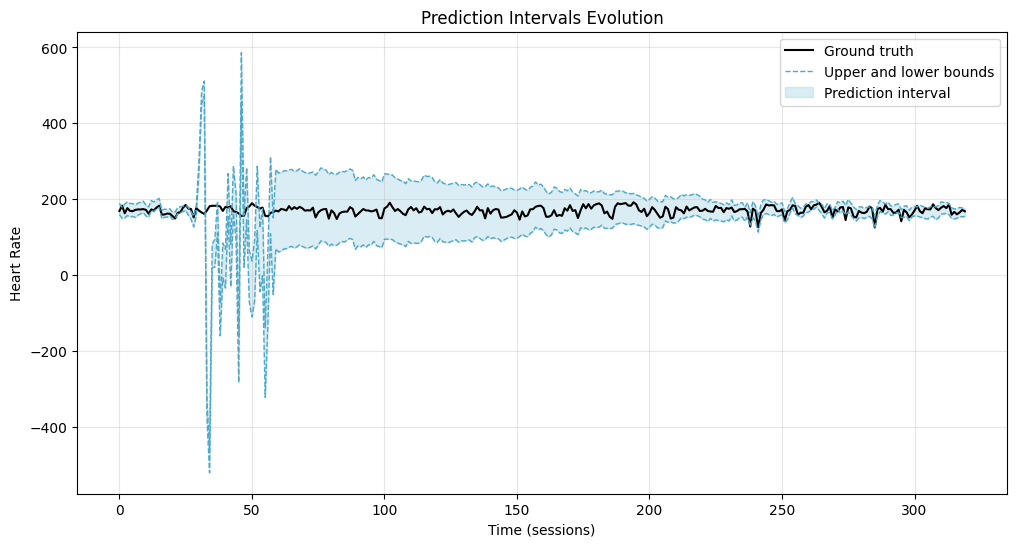

Figure saved


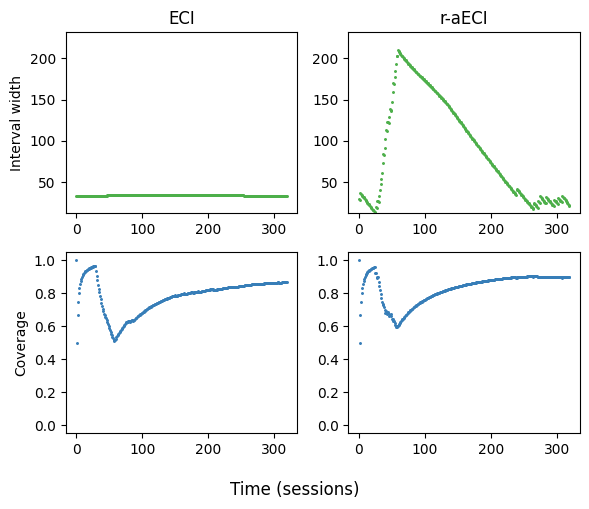

MHSC-07
0.8679245283018868 17.77945595189424 17.314518995851188
0.9272237196765498 20.62068030572931 20.50942901730616
Figure saved


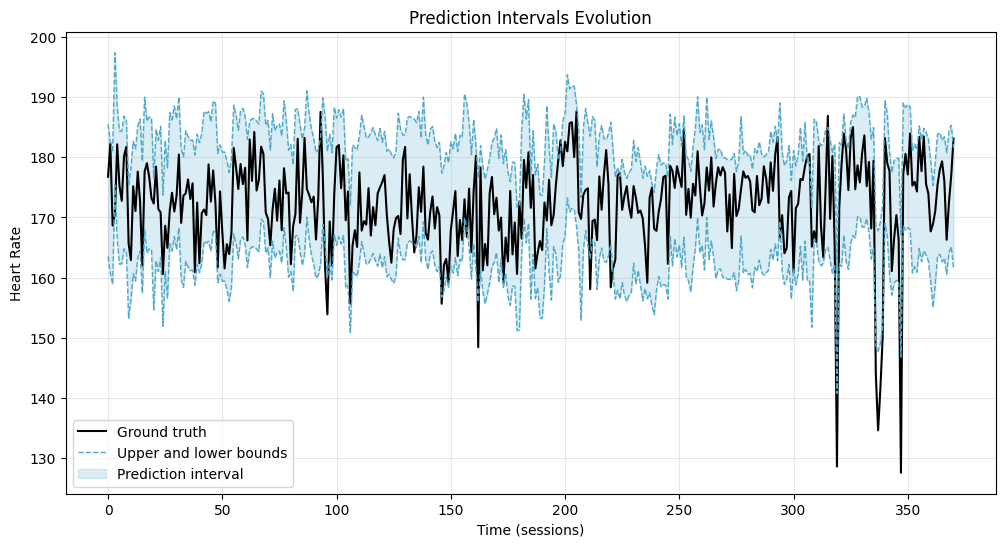

Figure saved


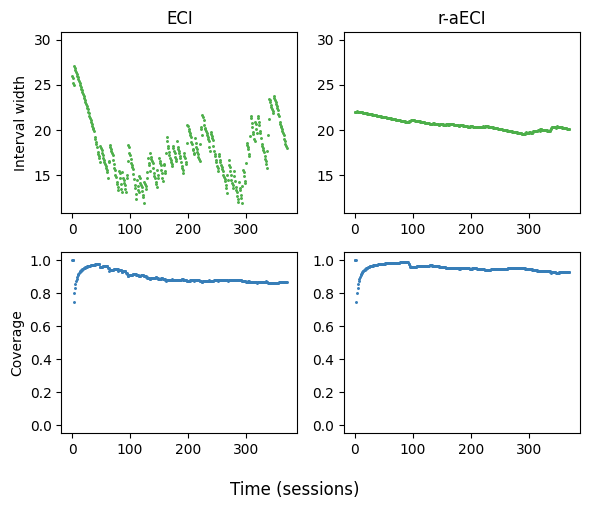

MHSC-08
0.896551724137931 28.900591189013614 28.738663968268725
0.8850574712643678 28.57942126864572 28.228941045824456
Figure saved


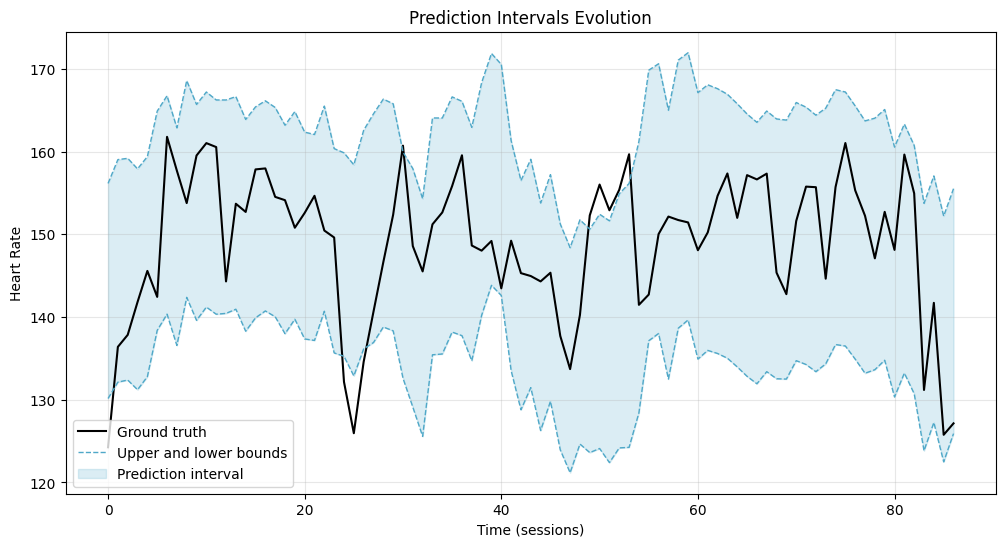

Figure saved


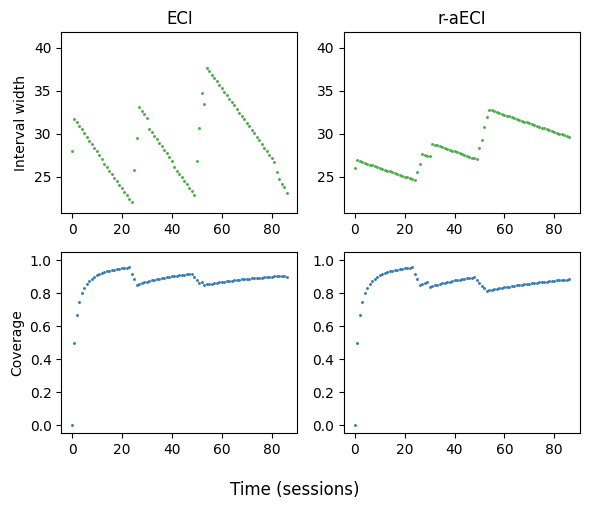

MHSC-10
0.936 21.57389853846671 21.471251889742632
0.928 23.435742012953668 23.29997239733757
Figure saved


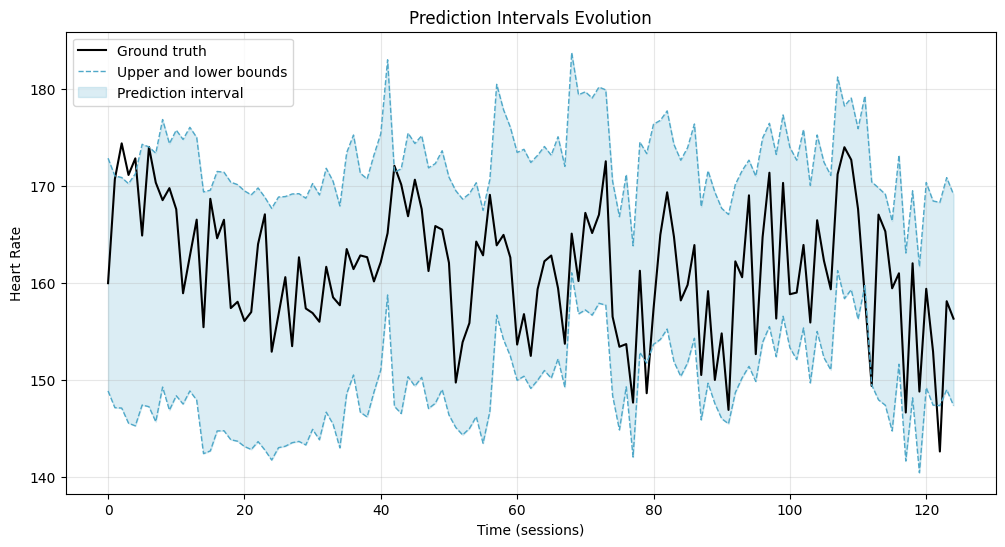

Figure saved


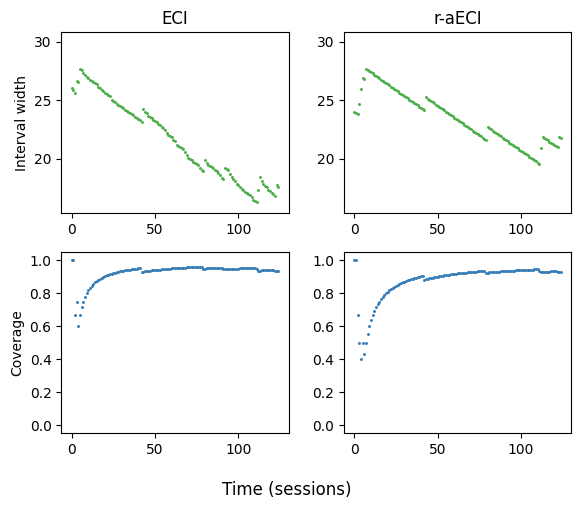

MHSC-11
0.9210526315789473 29.87642825833443 29.861694879829912
0.9210526315789473 27.148273960449327 26.82774111258655
Figure saved


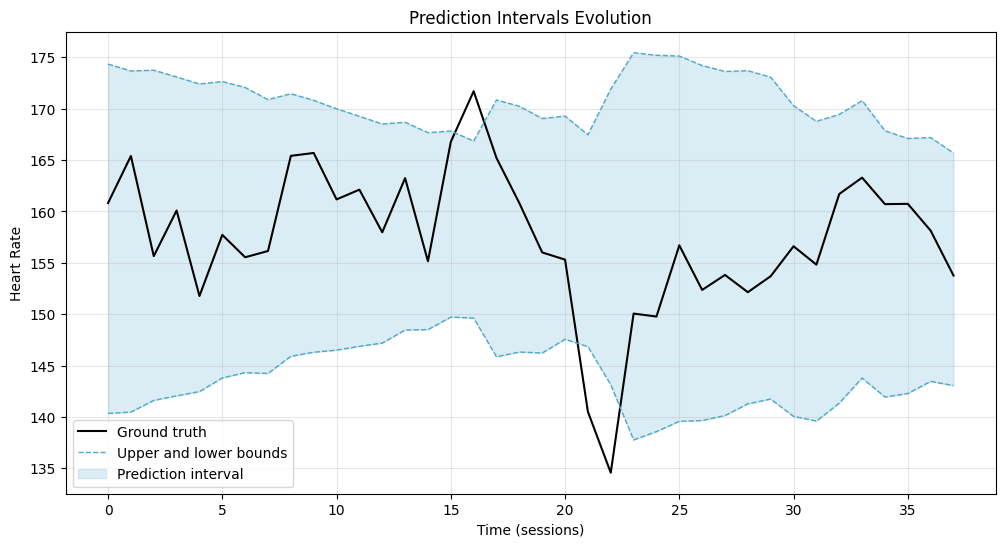

Figure saved


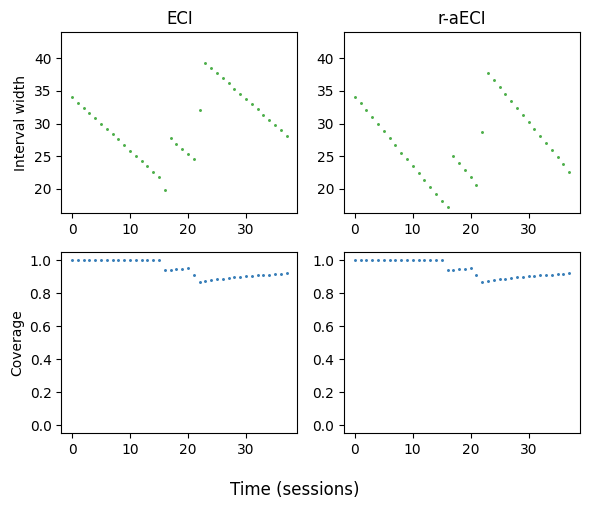

MHSC-14
0.8720538720538721 28.194474307671307 28.228685667382138
0.8787878787878788 28.385814131993655 28.16135299170145
Figure saved


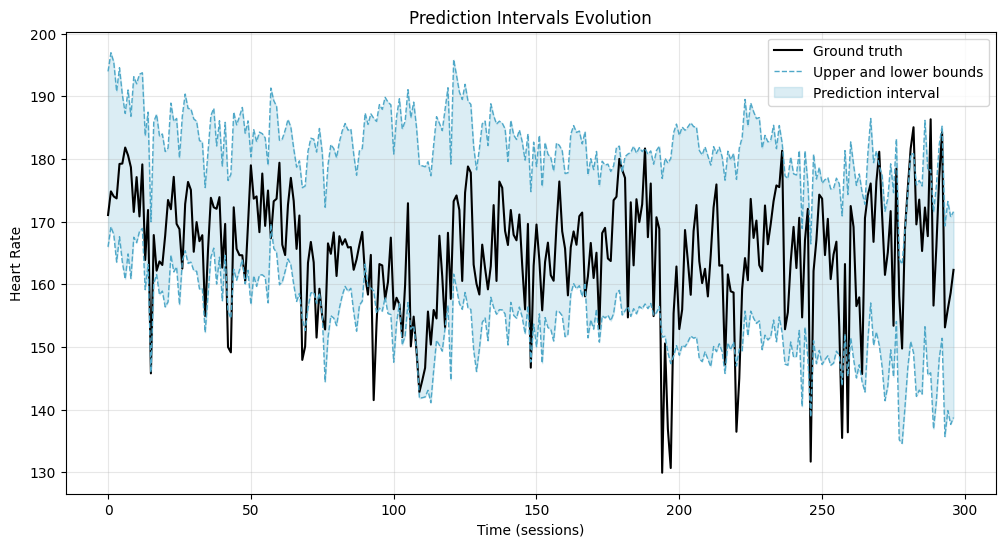

Figure saved


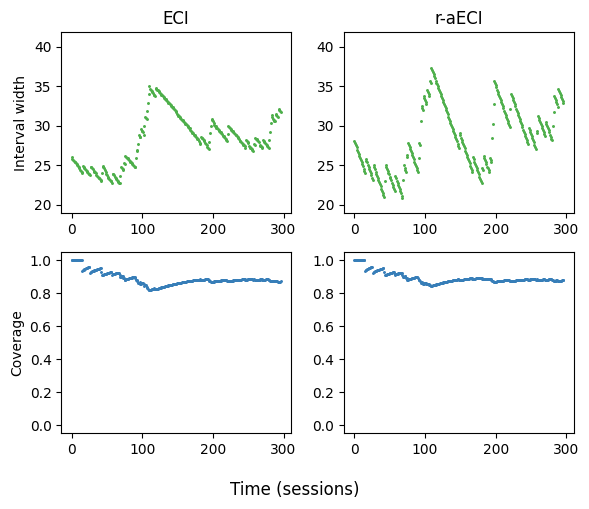

MHSC-16
0.8891752577319587 25.882754835904098 26.089816788893017
0.904639175257732 26.2076876429771 26.165379756126242
Figure saved


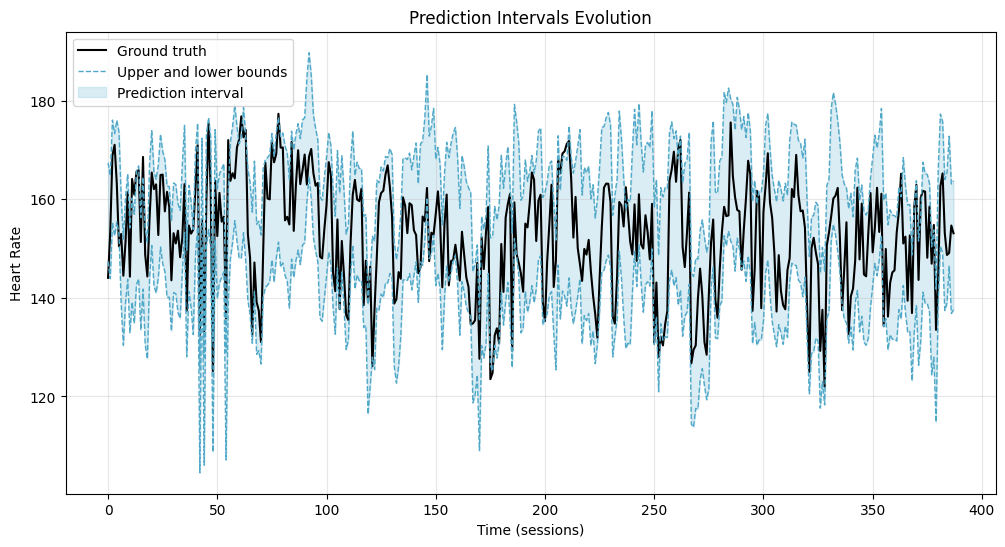

Figure saved


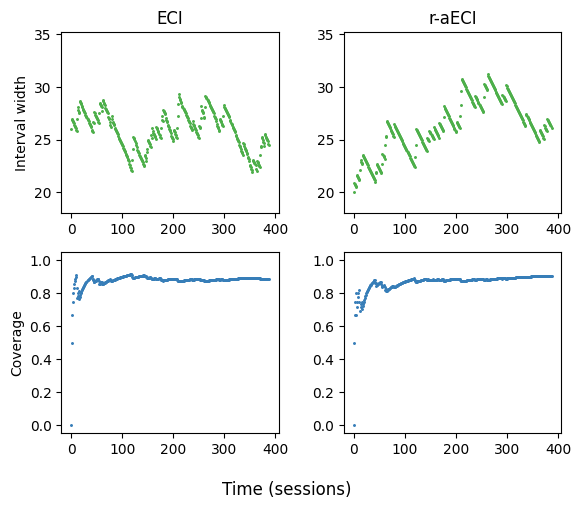

MHSC-17
0.890625 29.066088177339264 28.912960384615417
0.8932291666666666 29.715039195320127 29.53538431973746
Figure saved


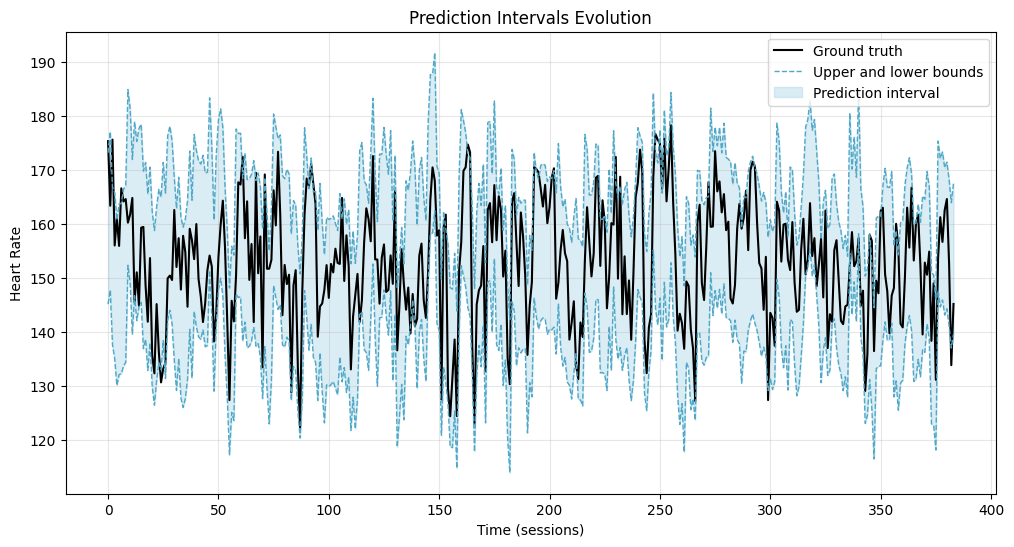

Figure saved


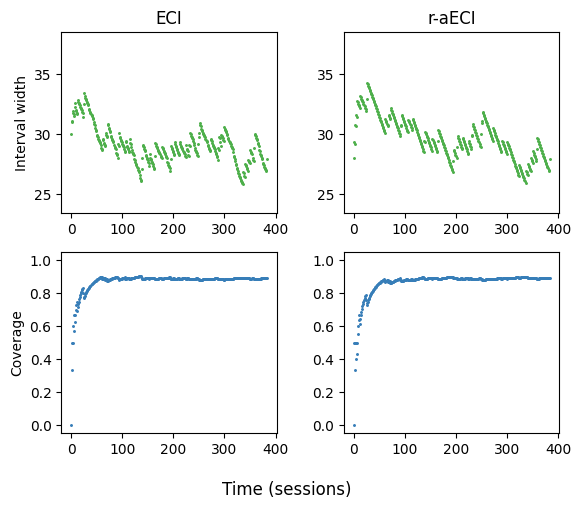

MHSC-18
0.8952702702702703 20.82060323994497 20.335142485306164
0.9155405405405406 20.98511973136719 20.88707316944391
Figure saved


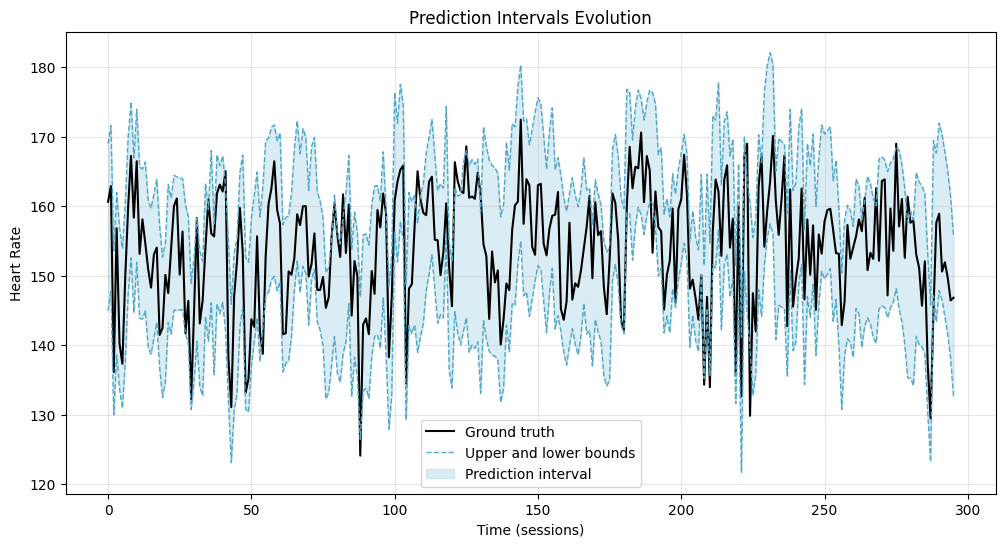

Figure saved


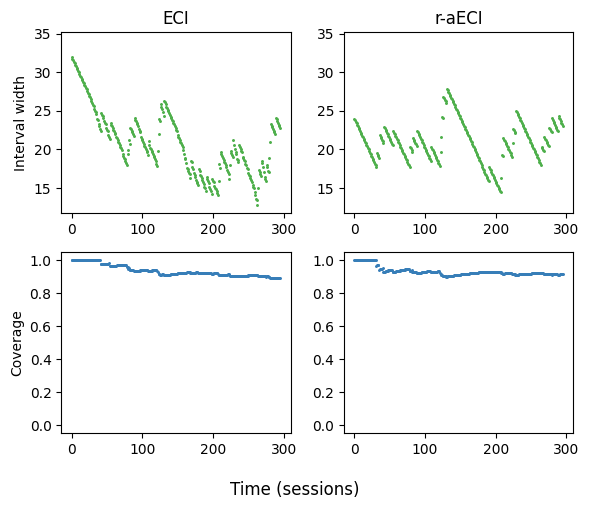

MHSC-19
0.89171974522293 21.890232160384137 21.446681505288552
0.9171974522292994 22.39748833195501 22.028071433315972
Figure saved


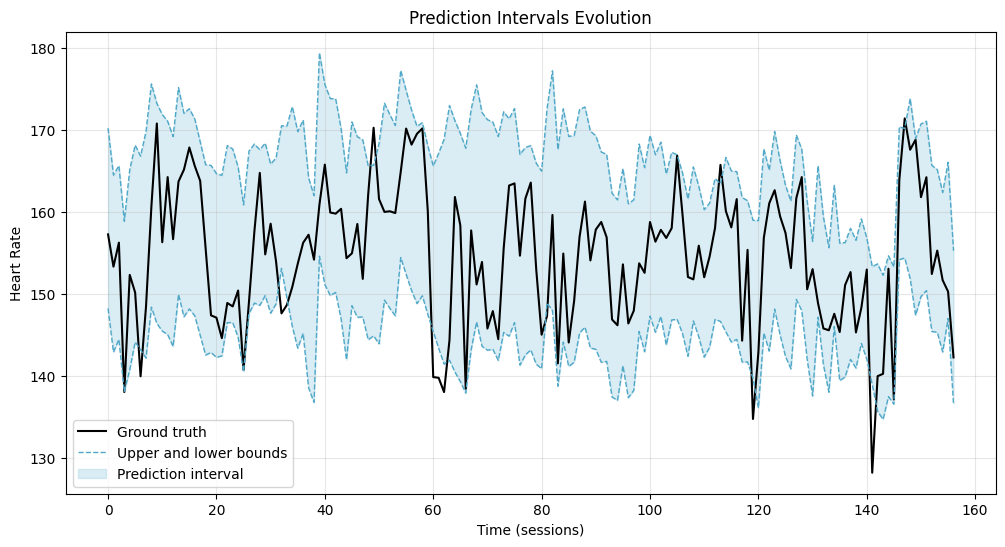

Figure saved


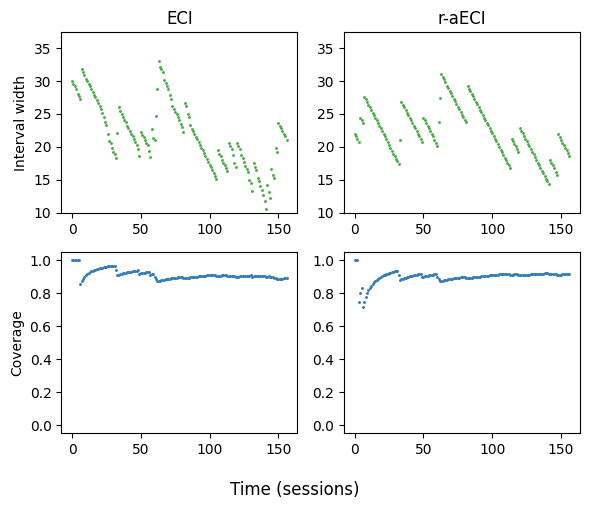

MHSC-20
0.8686440677966102 32.49087391600852 29.87169483344229
0.8686440677966102 32.38223215376053 29.096205724776212
Figure saved


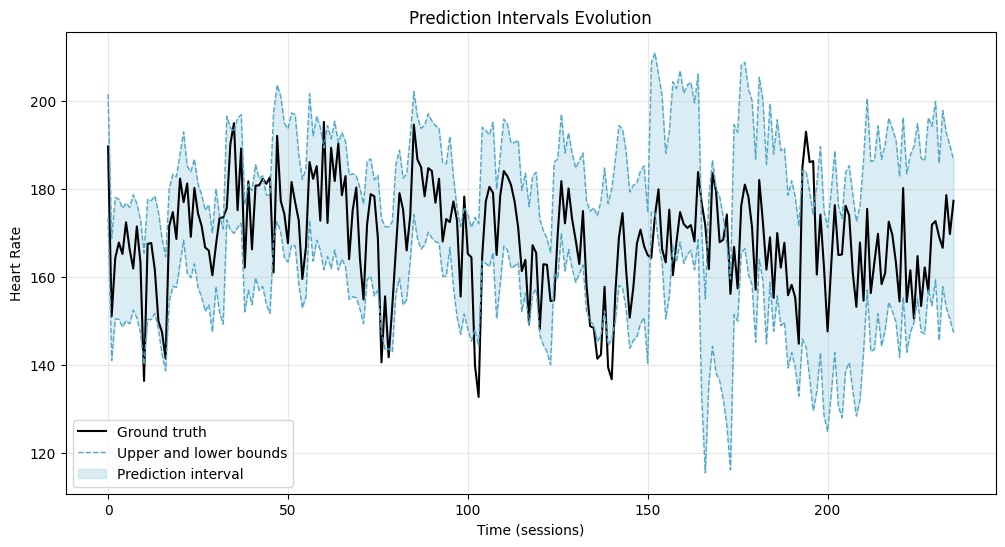

Figure saved


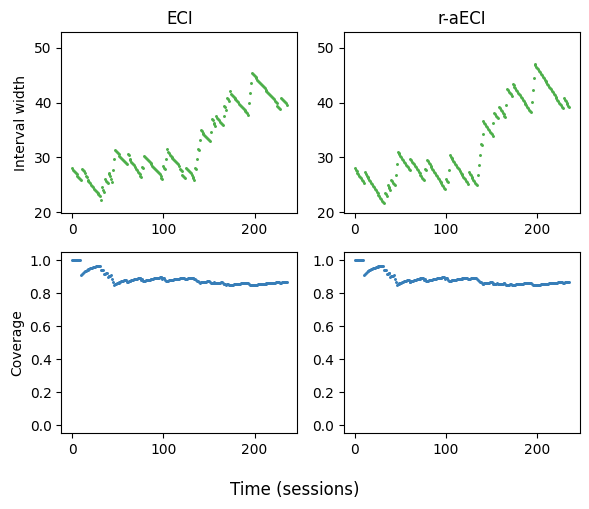

MHSC-22
0.9107692307692308 23.953463534218333 24.393588303180763
0.9138461538461539 21.951845901909774 21.61848872080583
Figure saved


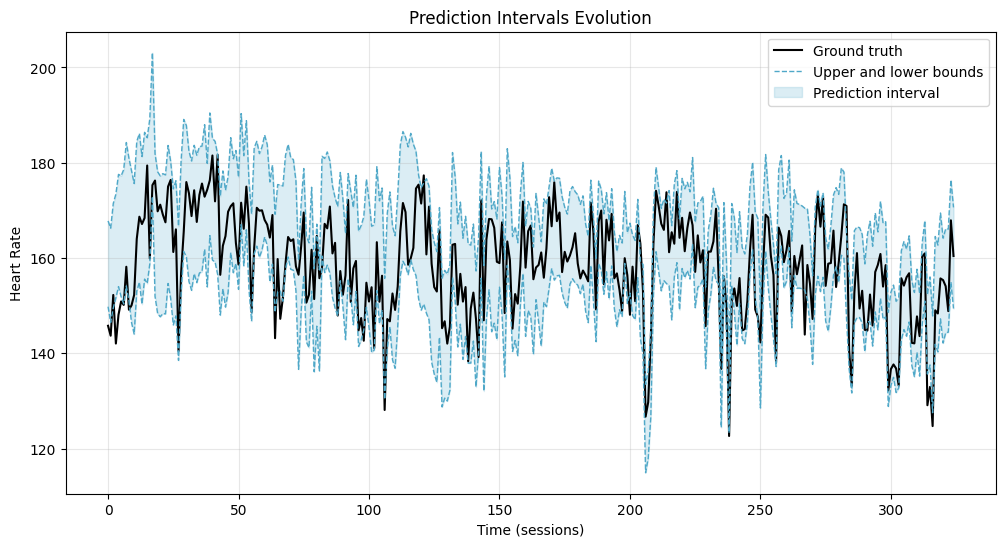

Figure saved


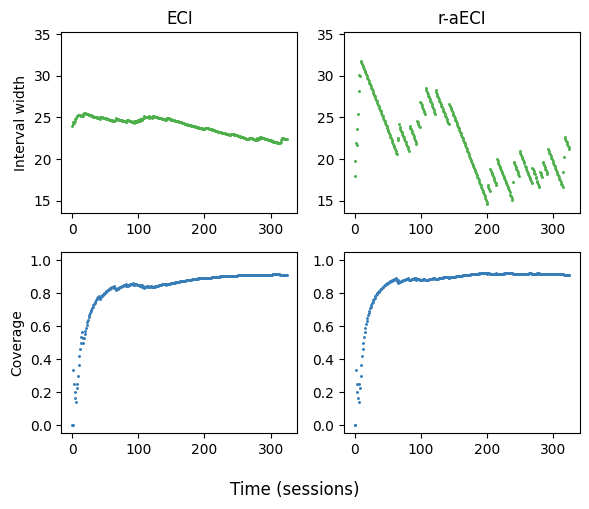

MHSC-23
0.9282296650717703 25.84166201515621 24.3695191046358
0.9234449760765551 25.438994561445885 25.631127408839234
Figure saved


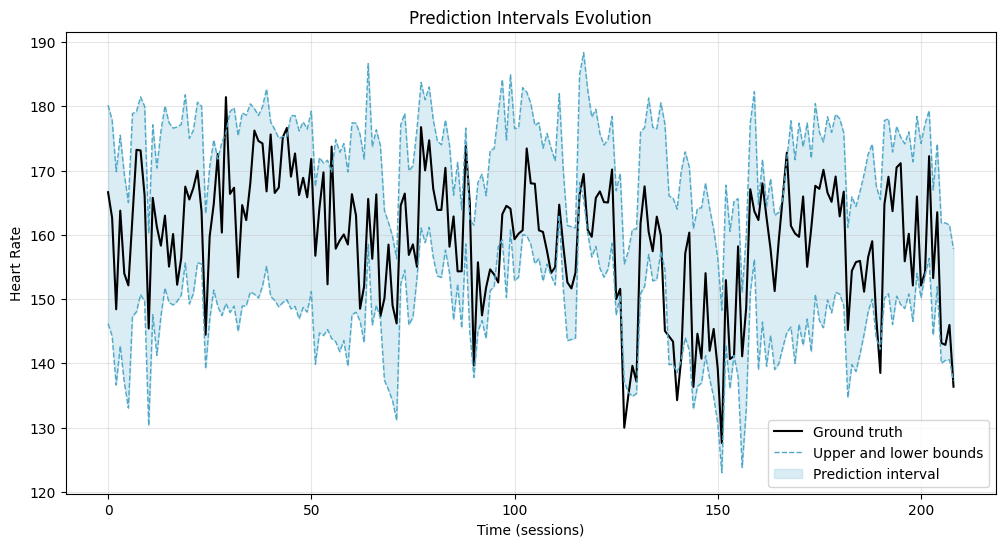

Figure saved


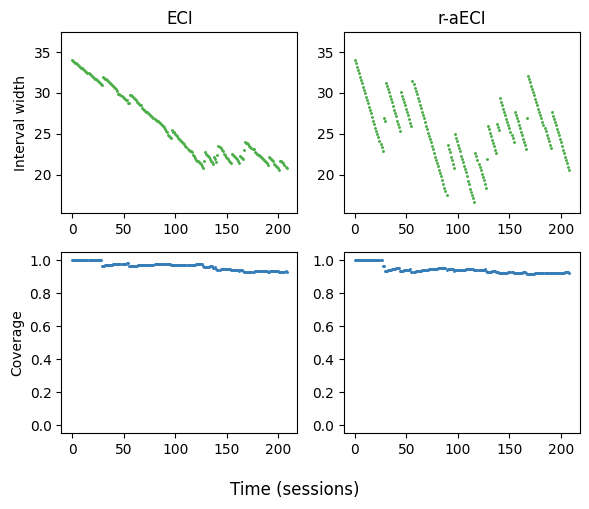

MHSC-25
0.8942857142857142 26.171128756715397 25.738749364998455
0.8914285714285715 25.415479697109205 24.649041850833868
Figure saved


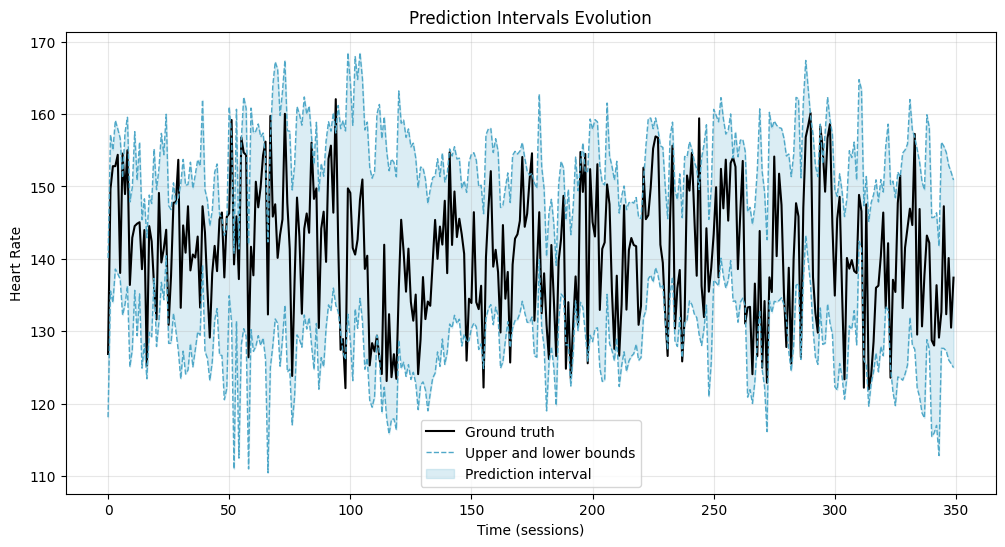

Figure saved


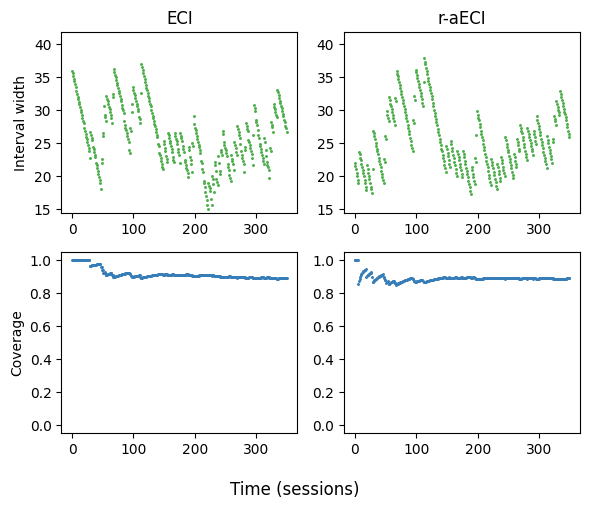

MHSC-26
0.8935185185185185 24.814542595900125 25.323920813227318
0.9120370370370371 30.65440780117287 30.26097692671189
Figure saved


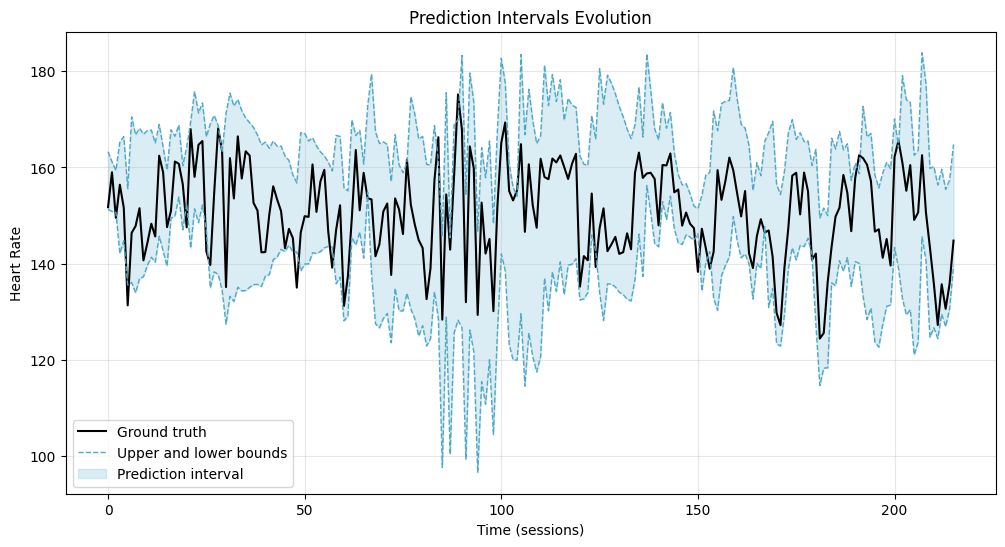

Figure saved


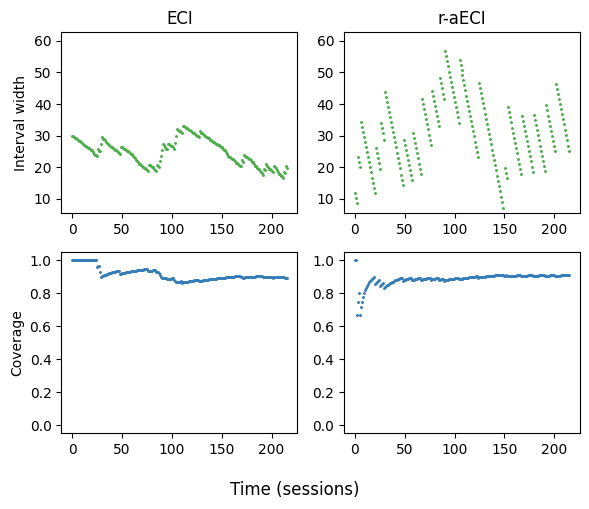

MHSC-29
0.8888888888888888 19.728137454270556 20.890695478781993
0.9166666666666666 21.811913576426463 20.71353188480151
Figure saved


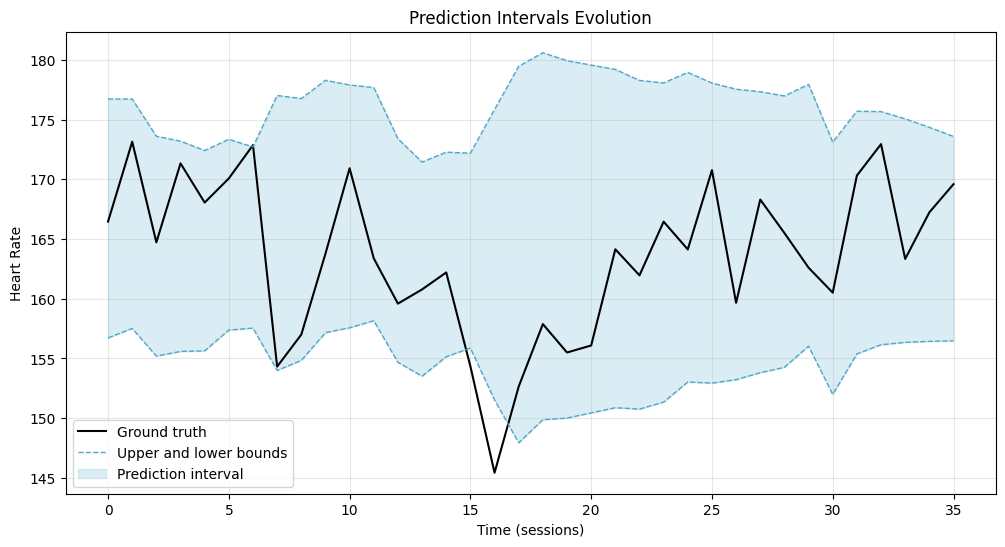

Figure saved


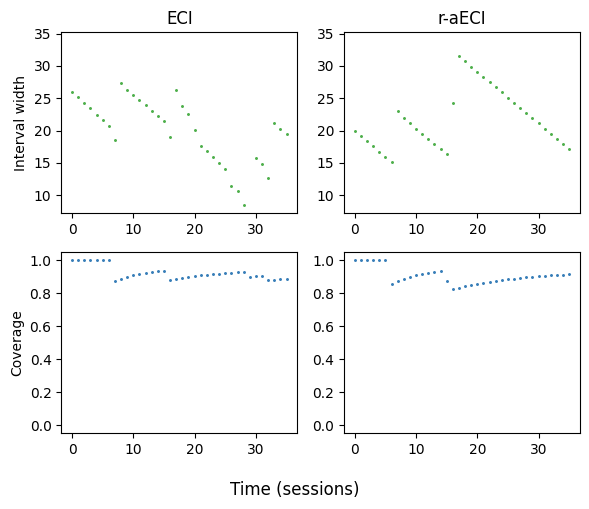

MHSC-32
0.8943089430894309 17.961444537309966 17.95746079638519
0.8943089430894309 17.99940955193528 17.99920545237319
Figure saved


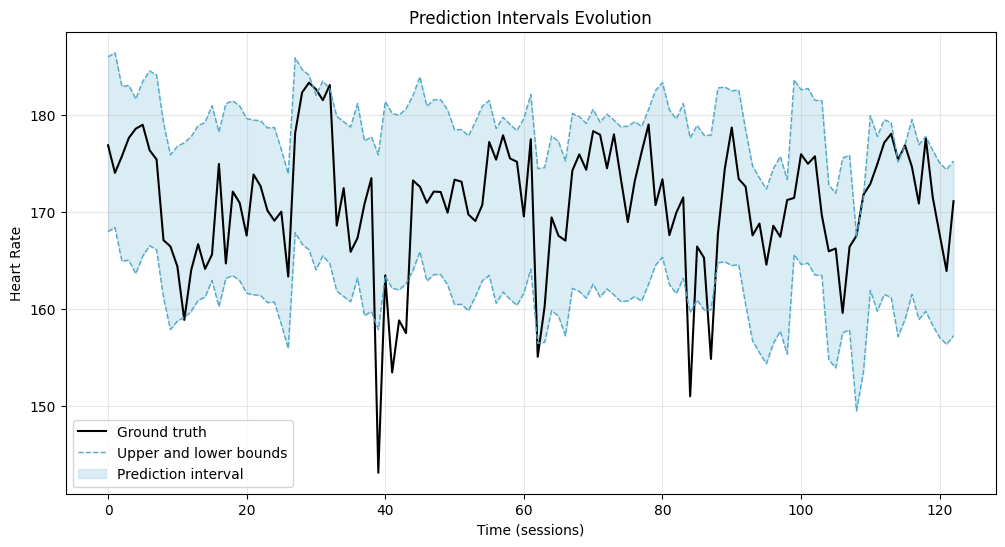

Figure saved


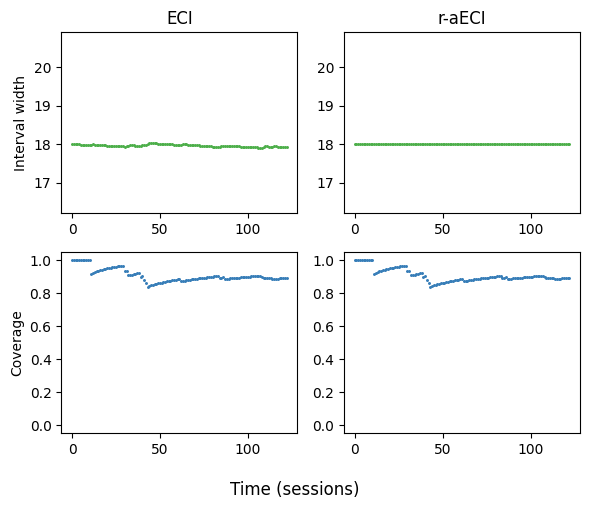

MHSC-35
0.892018779342723 27.559246453715208 27.66310057117579
0.9107981220657277 28.23648170699636 28.23522820023186
Figure saved


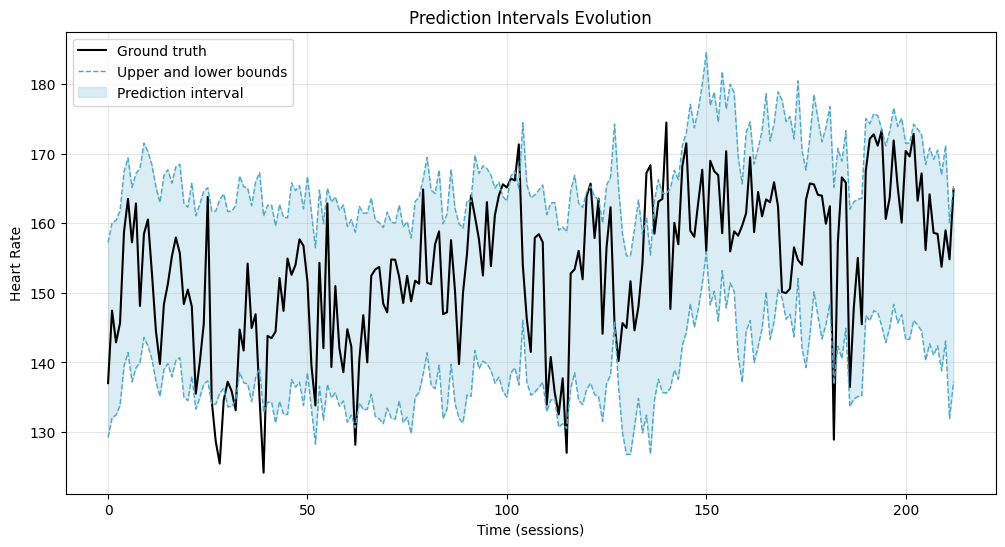

Figure saved


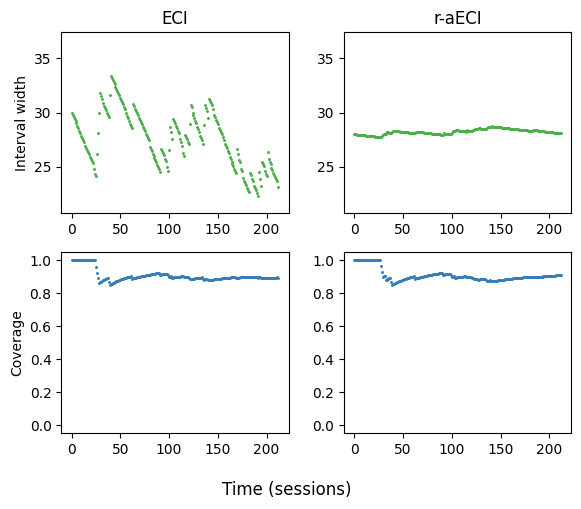

MHSC-39
0.9154228855721394 27.897423386705608 27.03673695456274
0.9154228855721394 29.07540878885385 28.132931513489893
Figure saved


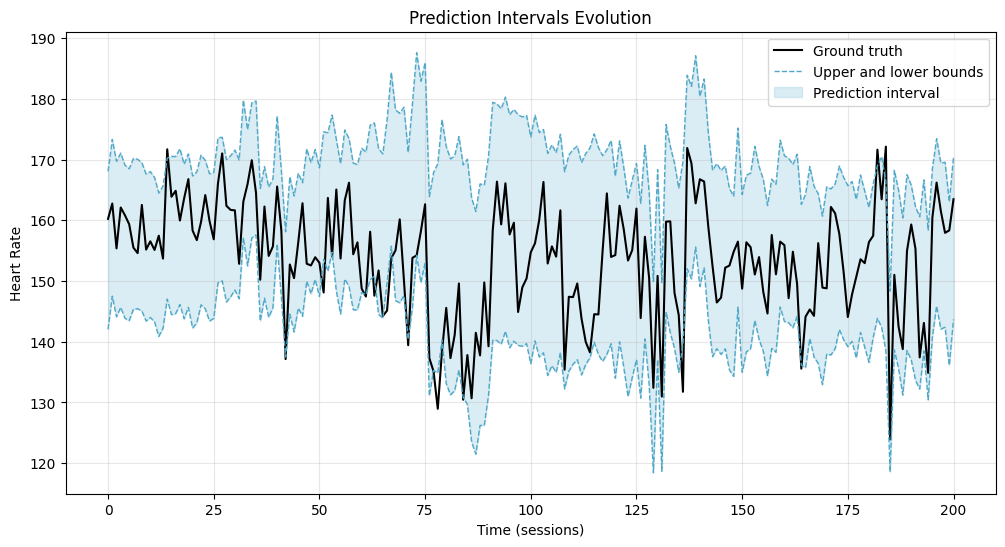

Figure saved


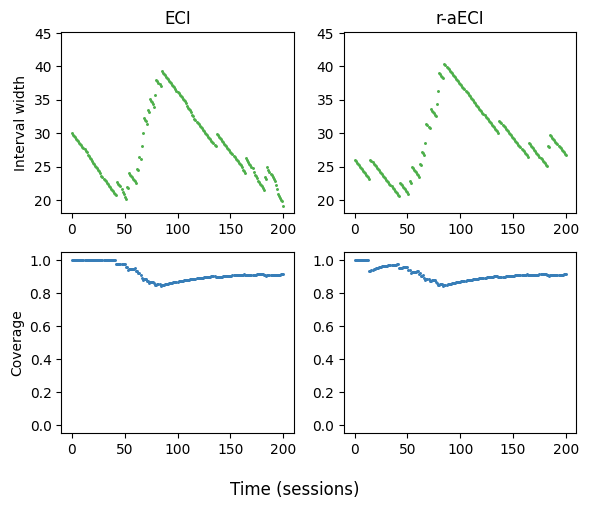

MHSC-41
0.9154929577464789 31.654218703349194 31.588975479855264
0.9154929577464789 31.1237077505862 31.25140907004686
Figure saved


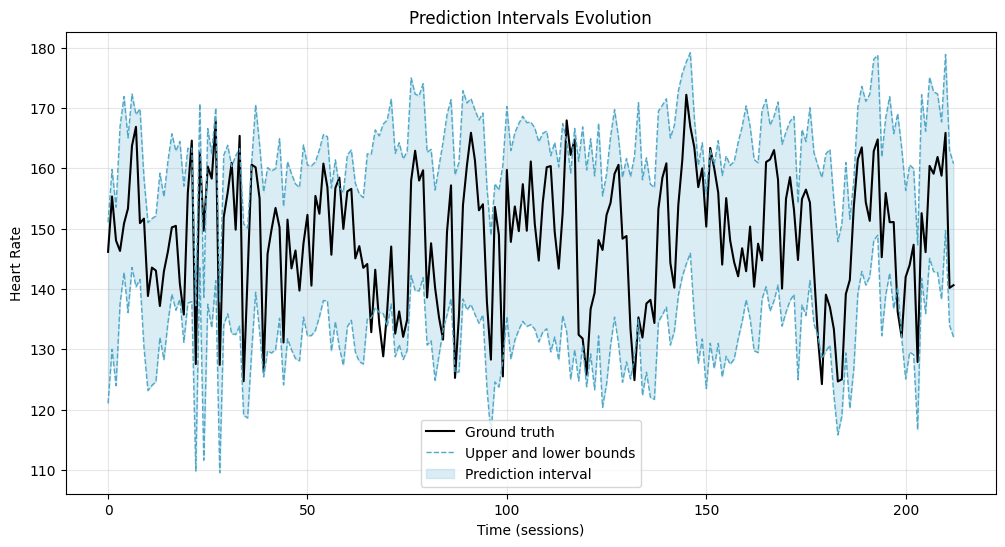

Figure saved


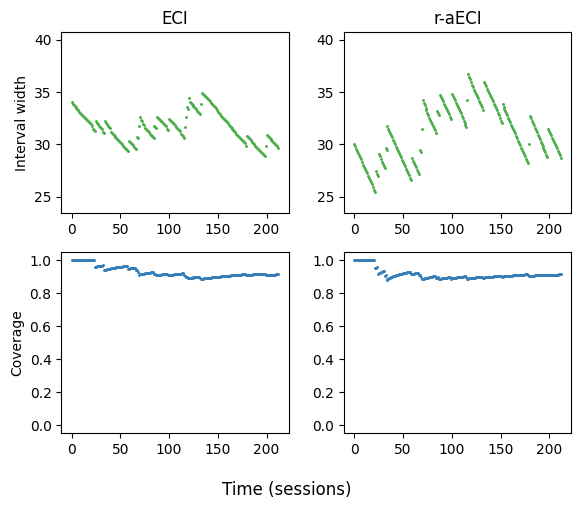

MHSC-45
0.8540145985401459 20.704595787742036 20.867193728194167
0.8759124087591241 27.50295165674431 28.251078261292548
Figure saved


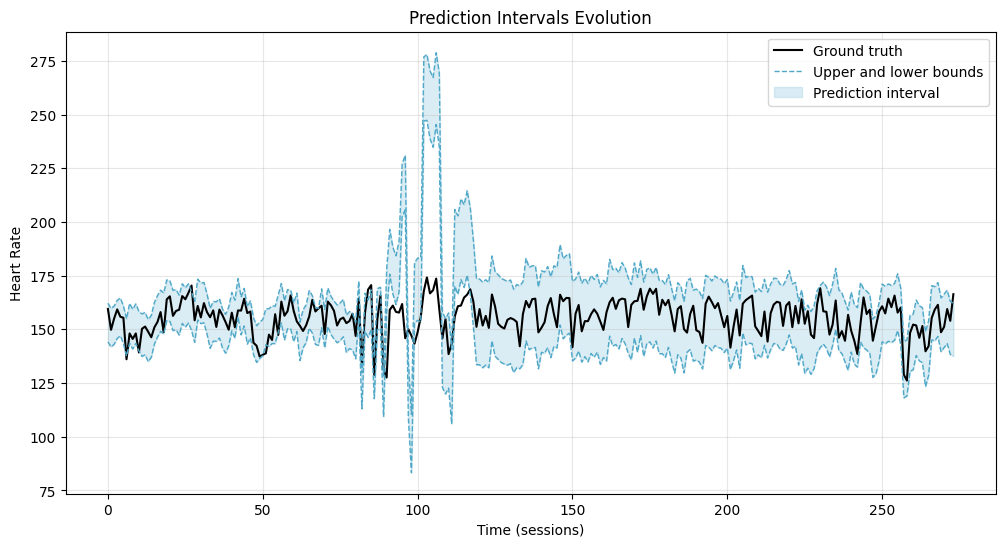

Figure saved


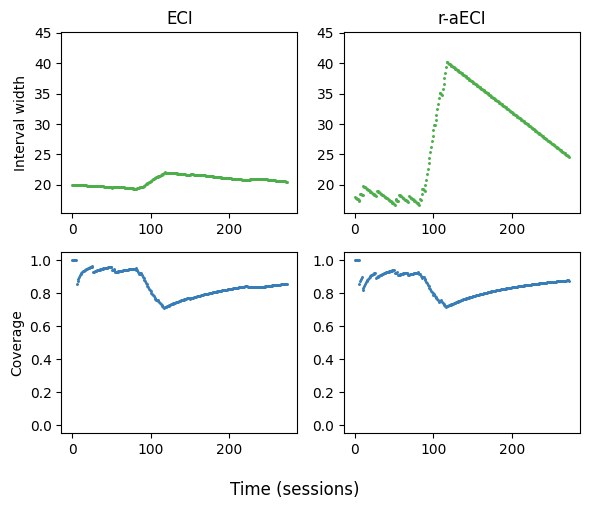

MHSC-47
0.9440559440559441 31.501021034915794 31.608834920357708
0.9300699300699301 28.248443789484156 28.79505943619222
Figure saved


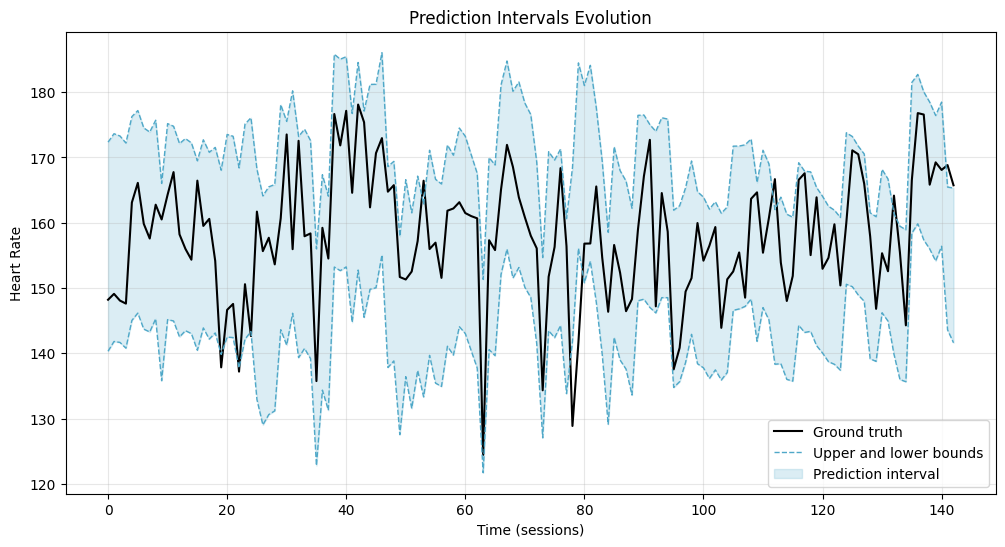

Figure saved


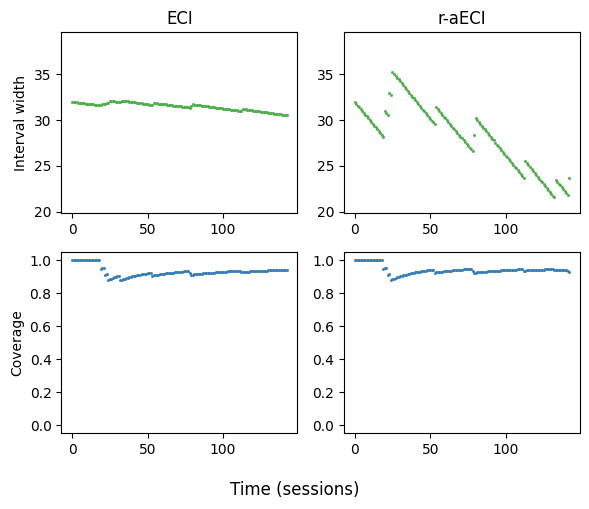

MHSC-49
0.8883248730964467 25.23124525617411 25.37621843816669
0.9086294416243654 27.307560924119418 27.39316892412245
Figure saved


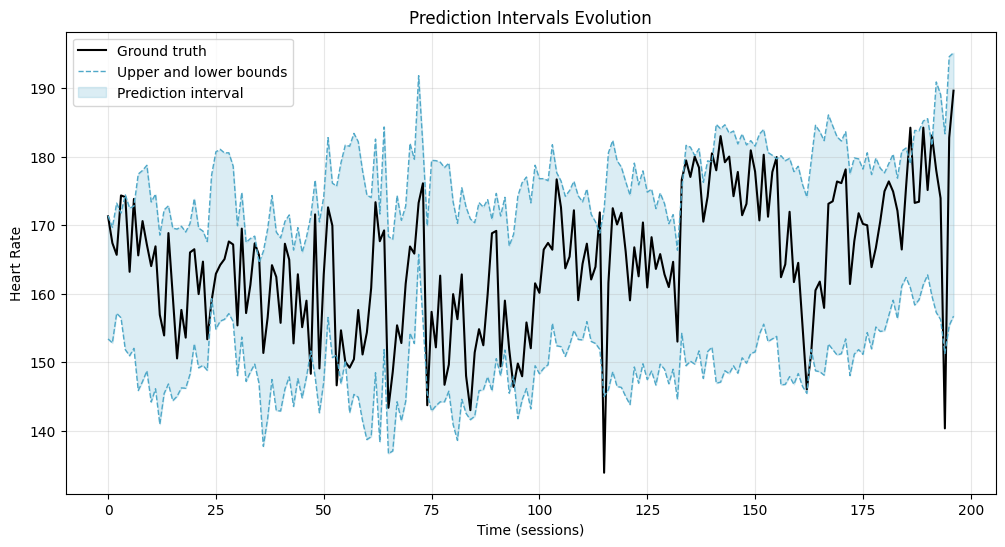

Figure saved


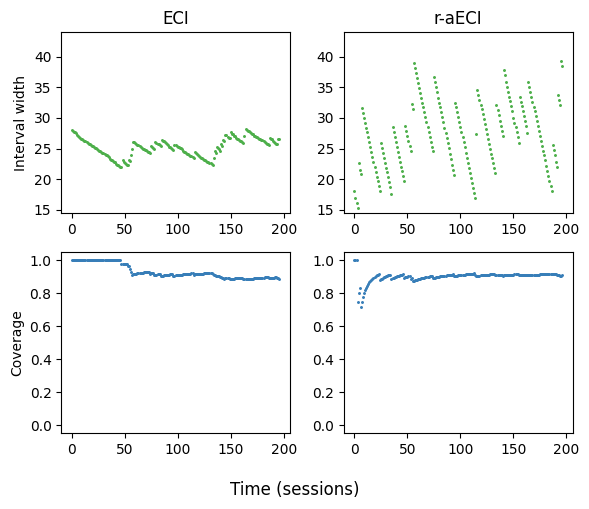

MHSC-51
0.8653061224489796 19.752680421939093 19.36239669068027
0.8734693877551021 19.65619712589326 18.719324785655203
Figure saved


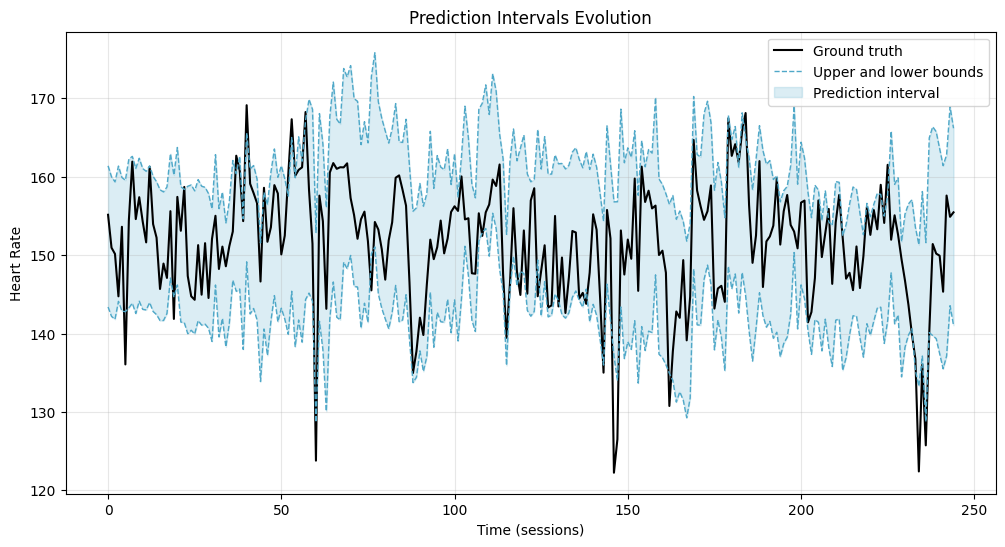

Figure saved


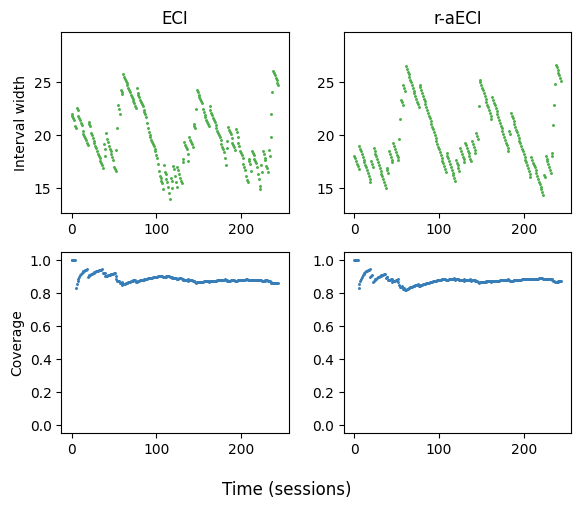

MHSC-53
0.8954248366013072 28.438807130309613 28.36288064164023
0.9019607843137255 27.972386608974737 27.660466683570064
Figure saved


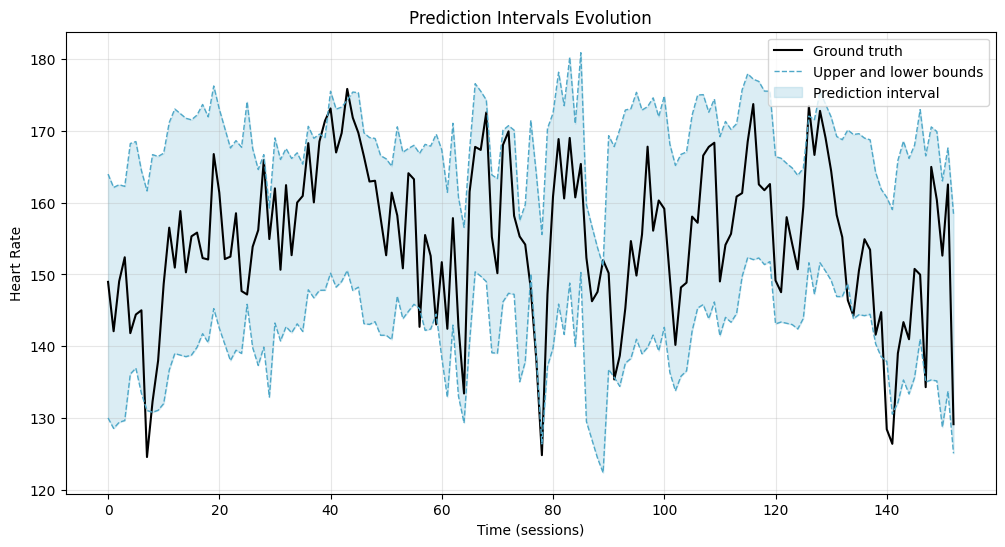

Figure saved


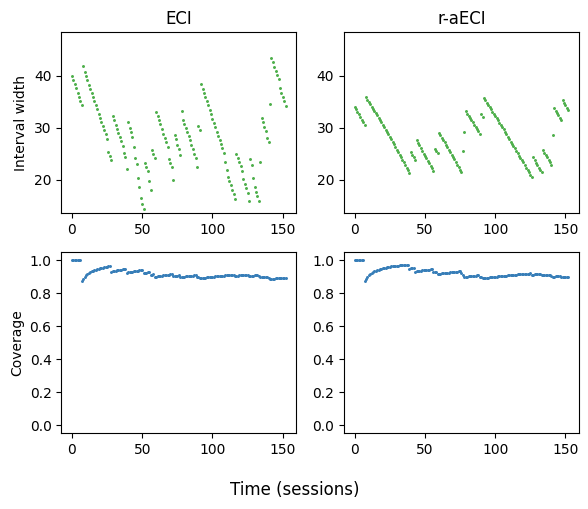

MHSC-54
0.9072164948453608 34.6441698650368 34.8191121056376
0.9587628865979382 34.507298563326216 33.24932364654785
Figure saved


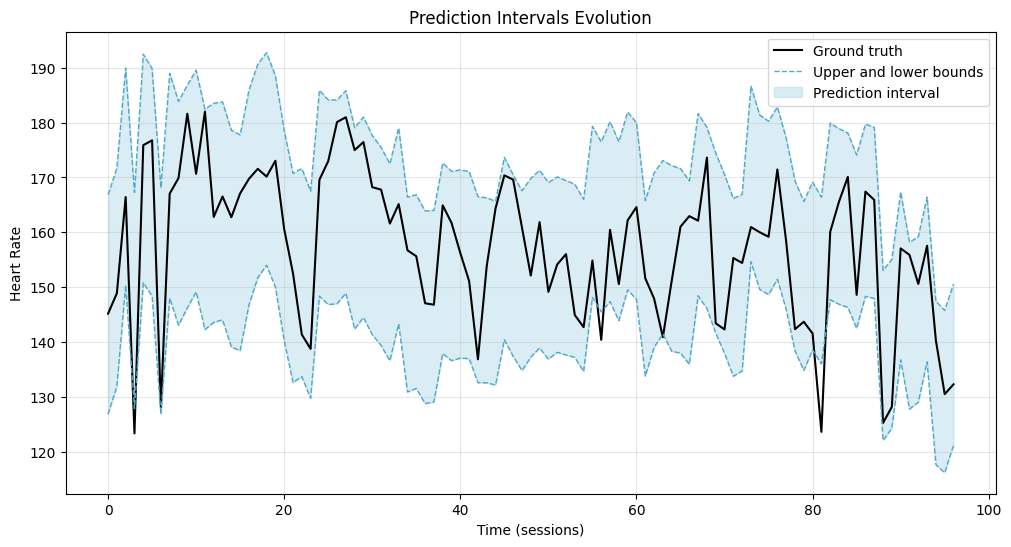

Figure saved


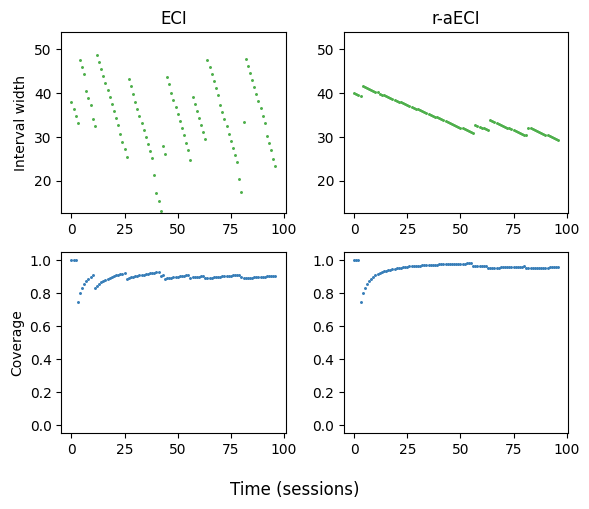

MHSC-55
0.950354609929078 30.17359783682297 30.07575037124687
0.9184397163120568 25.822610755040028 25.79812210036428
Figure saved


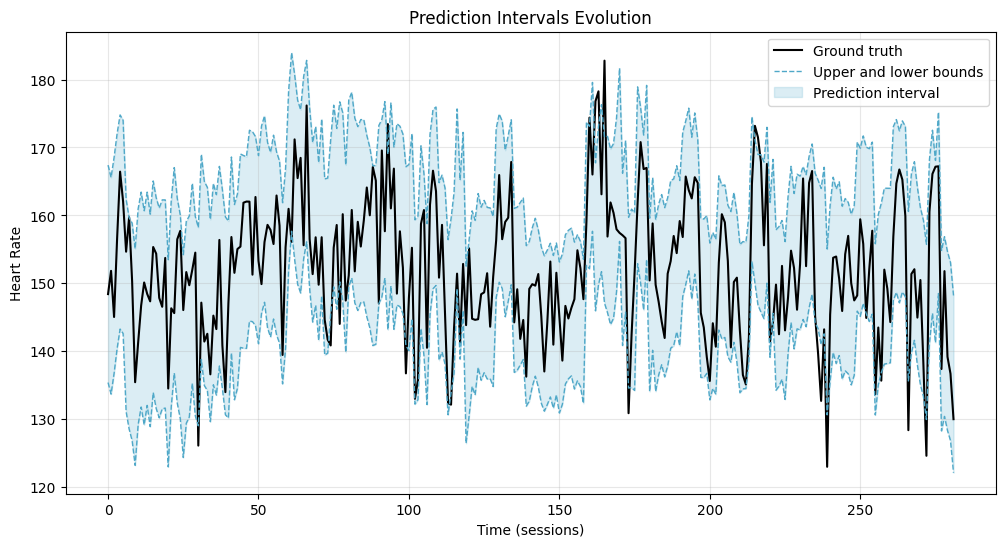

Figure saved


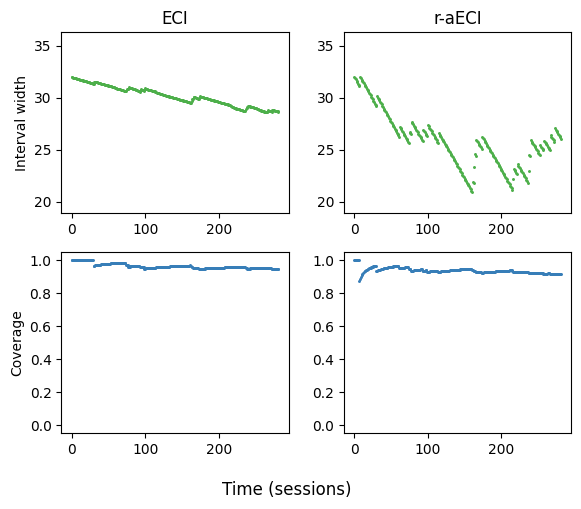

MHSC-56
0.8773584905660378 18.323499091461557 18.05032090236807
0.9150943396226415 20.159394881572414 19.76641664165527
Figure saved


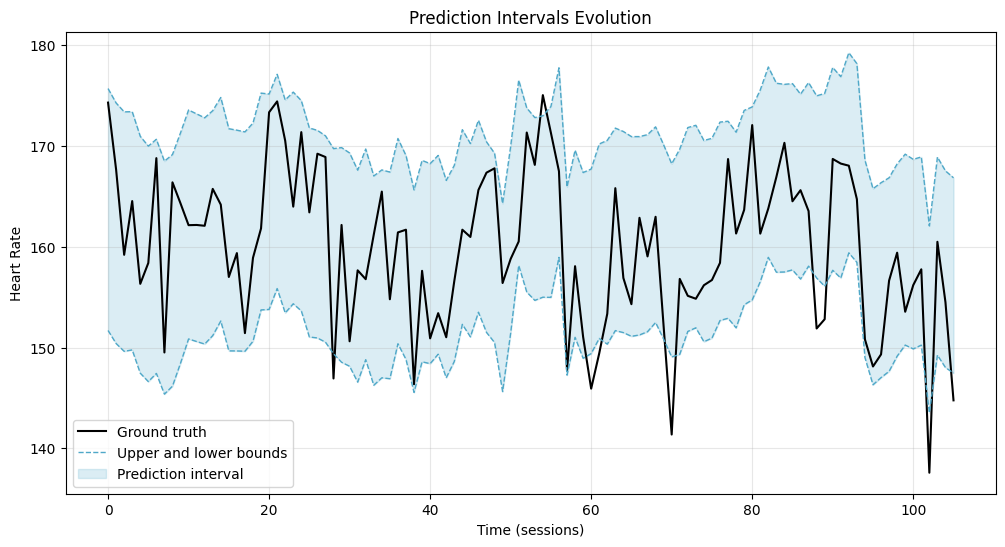

Figure saved


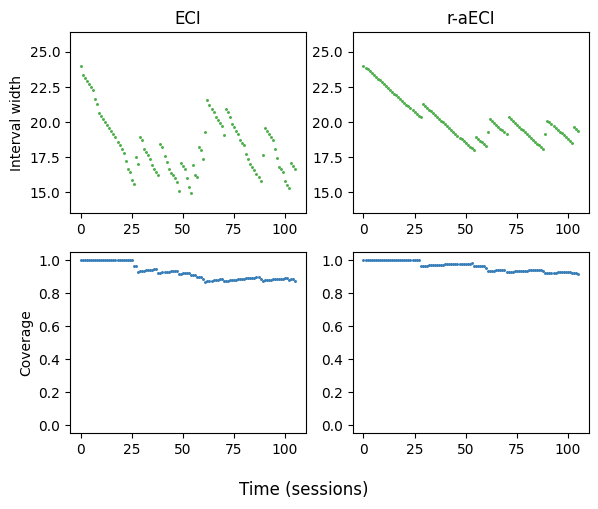

MHSC-59
0.9096774193548387 25.708050384300265 24.805968453638457
0.9096774193548387 25.822786758217568 26.12260926144762
Figure saved


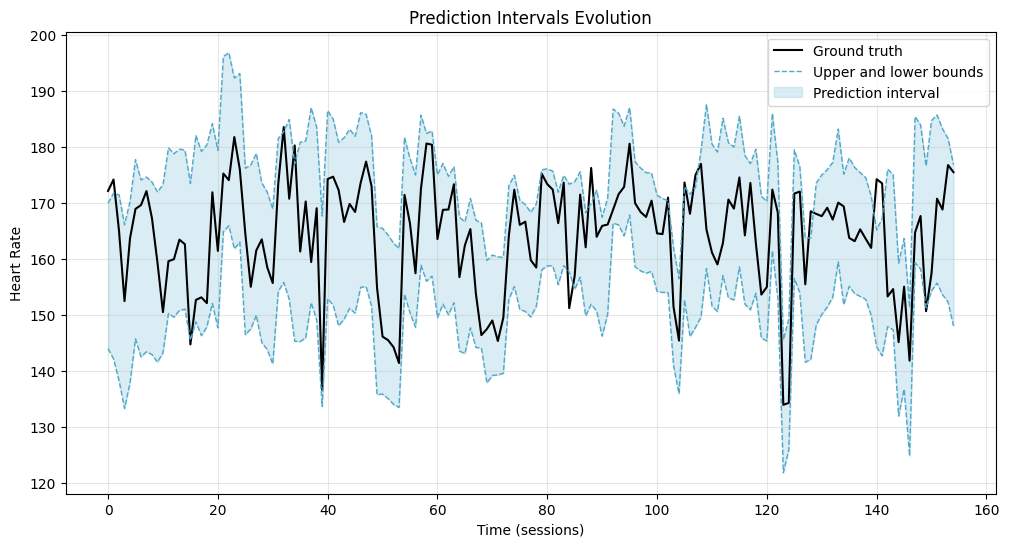

Figure saved


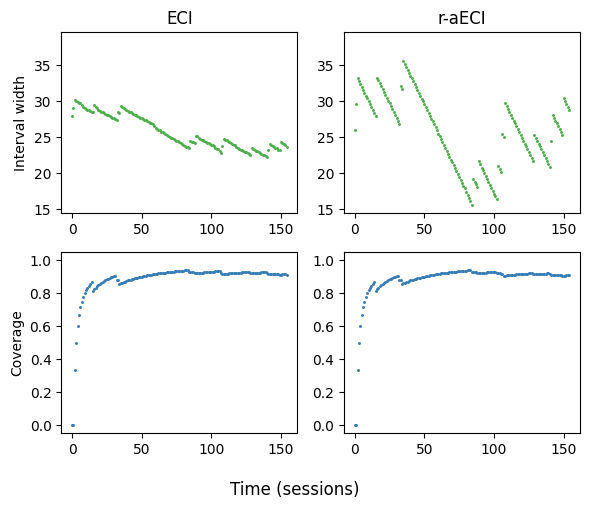

MHSC-60
0.896551724137931 33.68032503603403 33.662850402649696
0.896551724137931 32.1265500686095 32.45104522616353
Figure saved


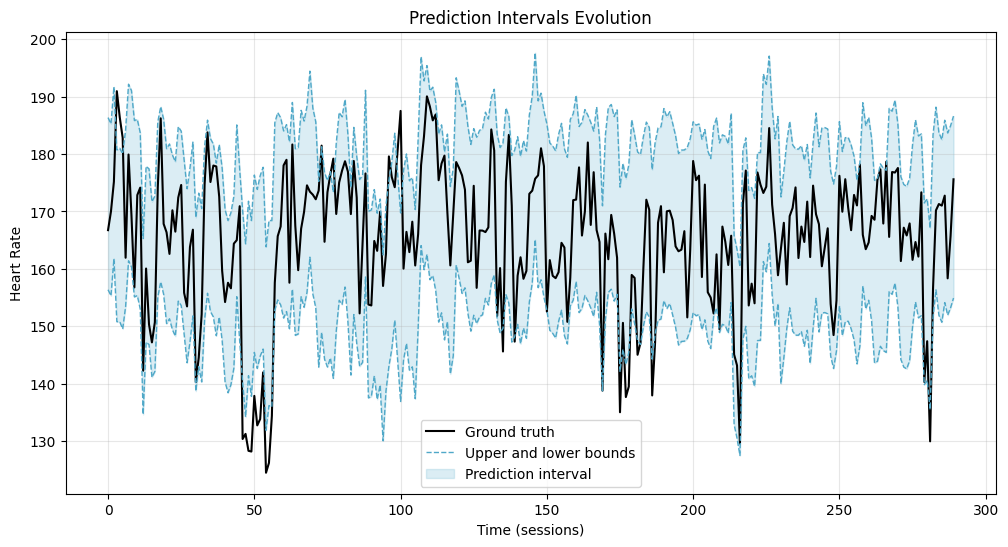

Figure saved


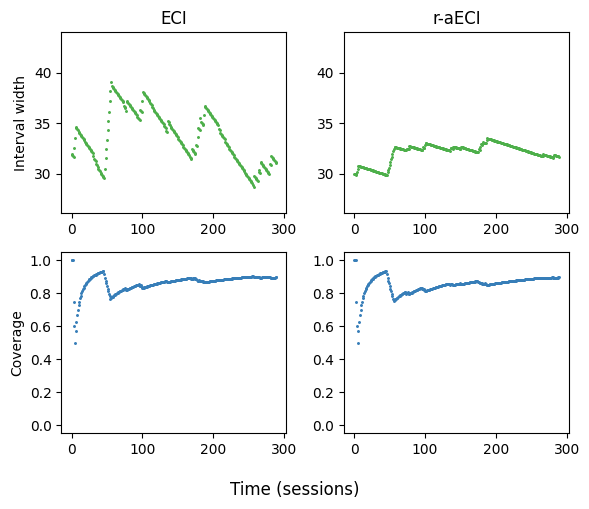

MHSC-62
0.9459459459459459 31.113547117185306 31.326010802664783
0.918918918918919 28.60672639645012 28.723598209350826
Figure saved


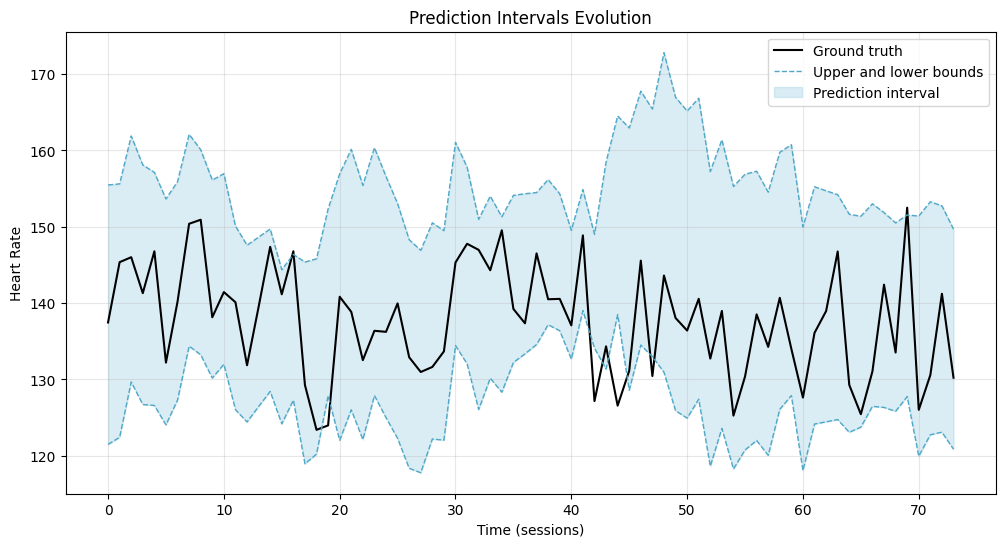

Figure saved


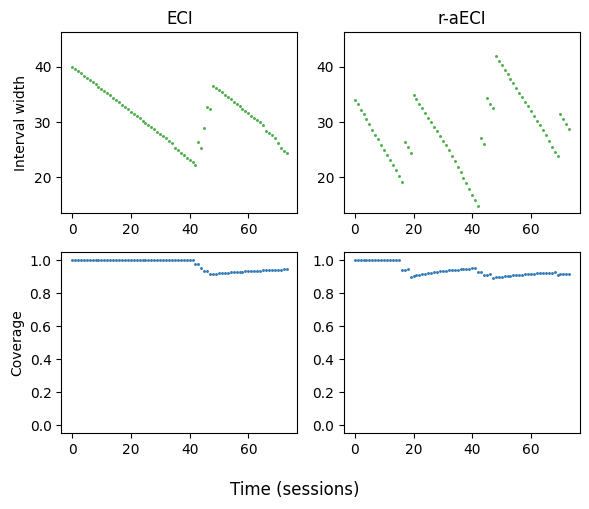

MHSC-65
0.8877005347593583 22.545772311799777 21.577772849240887
0.9144385026737968 24.39160640678626 23.395407288121703
Figure saved


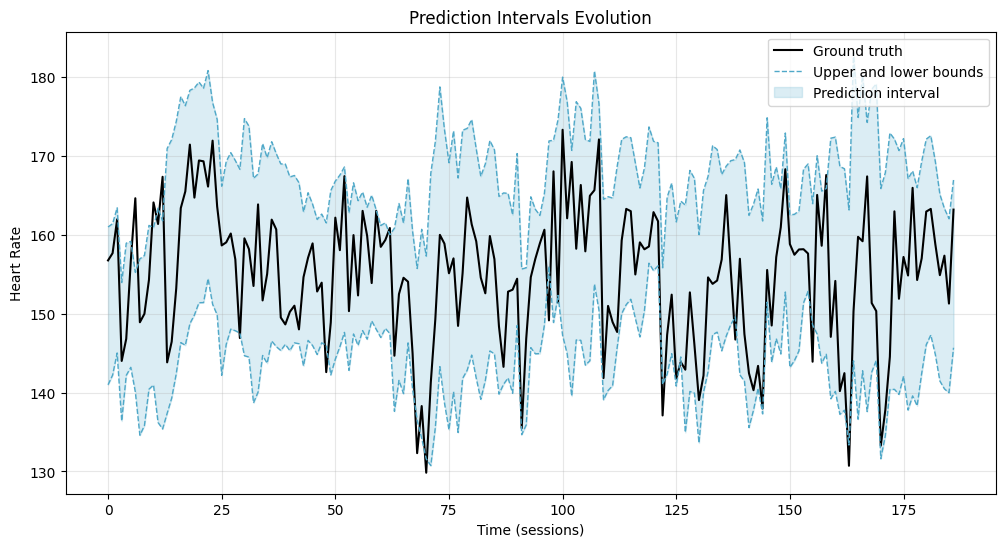

Figure saved


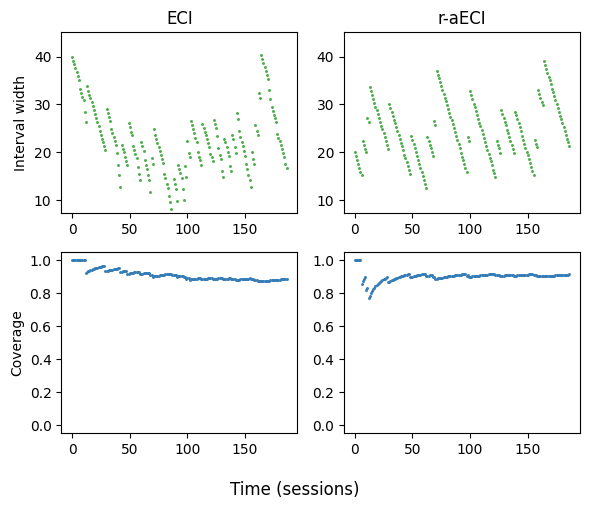

MHSC-66
0.8901098901098901 25.95054658556722 25.128759774379375
0.8901098901098901 29.40404165128053 28.679398908108908
Figure saved


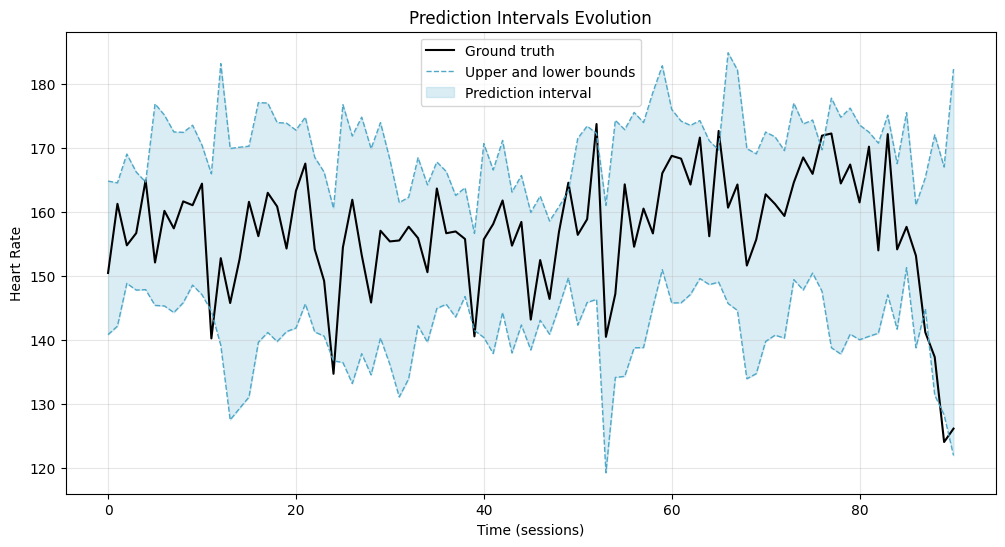

Figure saved


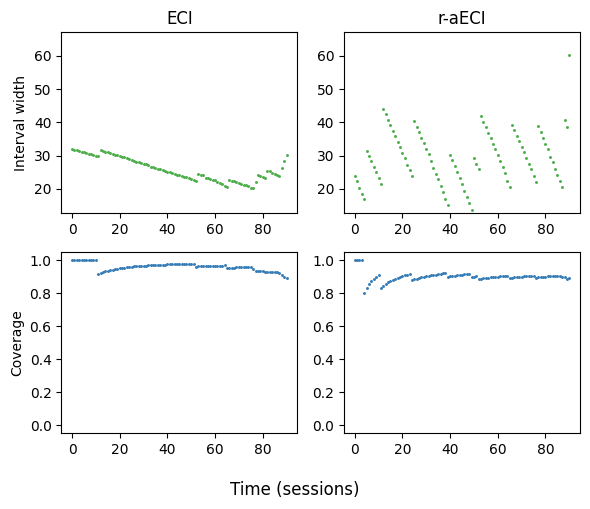

MHSC-67
0.9387755102040817 28.145727034130363 27.94740524646261
0.8979591836734694 25.782979010157323 25.831212642349726
Figure saved


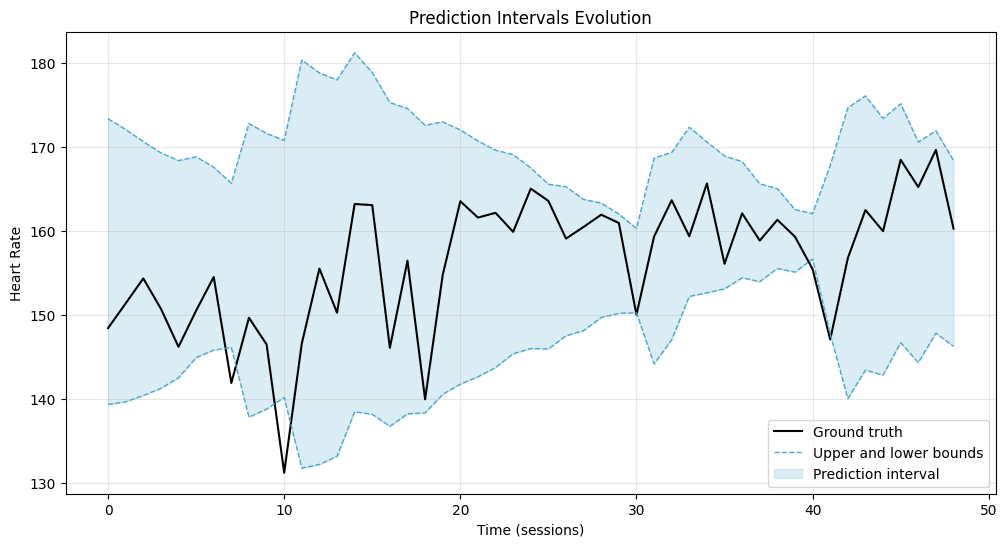

Figure saved


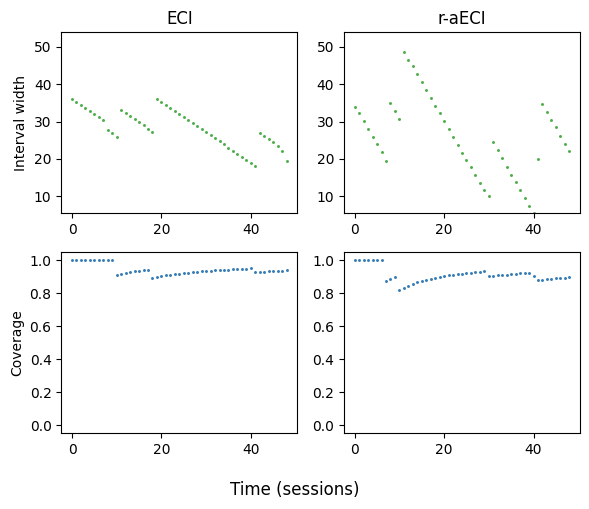

MHSC-68
0.8979591836734694 46.75672601135166 45.797061324987496
0.9183673469387755 47.90454236395125 47.42623779561086
Figure saved


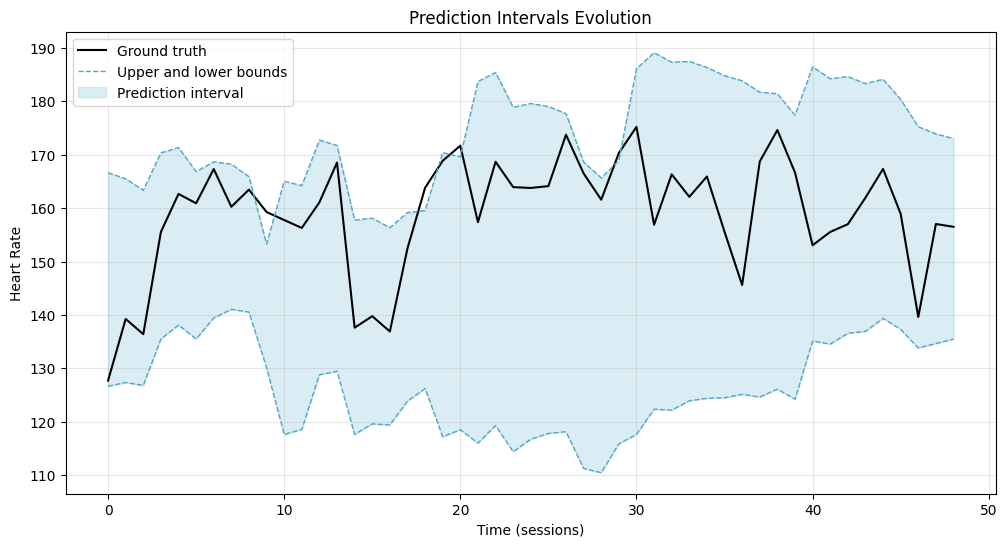

Figure saved


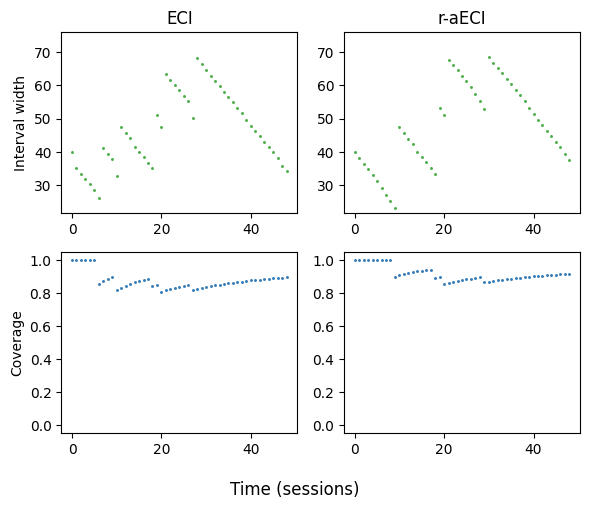

MHSC-69
0.9574468085106383 35.598903979753985 35.55329098009037
0.9361702127659575 39.607461072212985 38.39999999999998
Figure saved


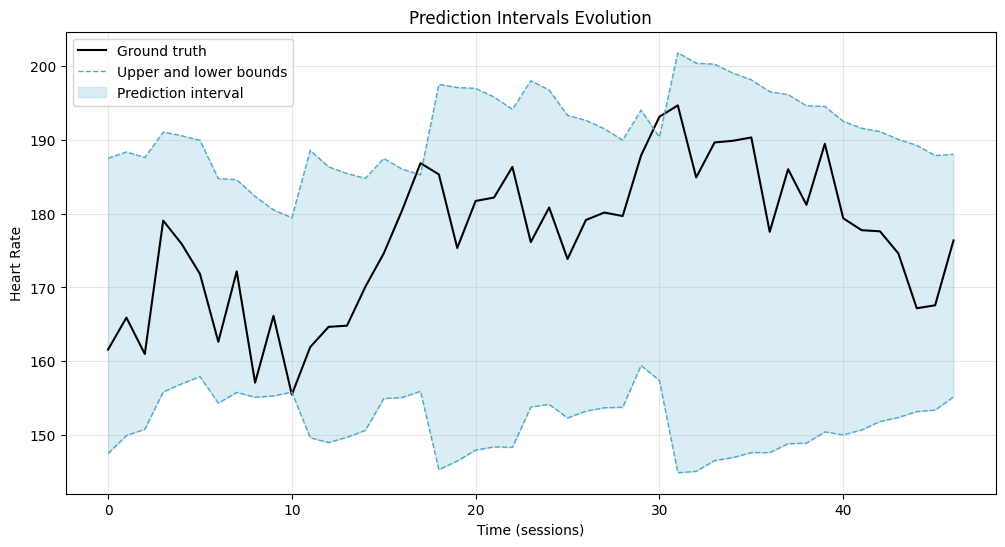

Figure saved


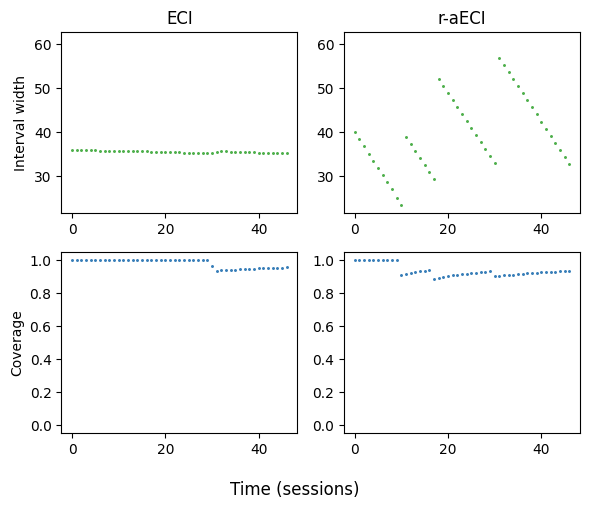

MHSC-71
0.898989898989899 17.904753021100596 17.35687745906432
0.9090909090909091 19.46471483761398 19.156943132727804
Figure saved


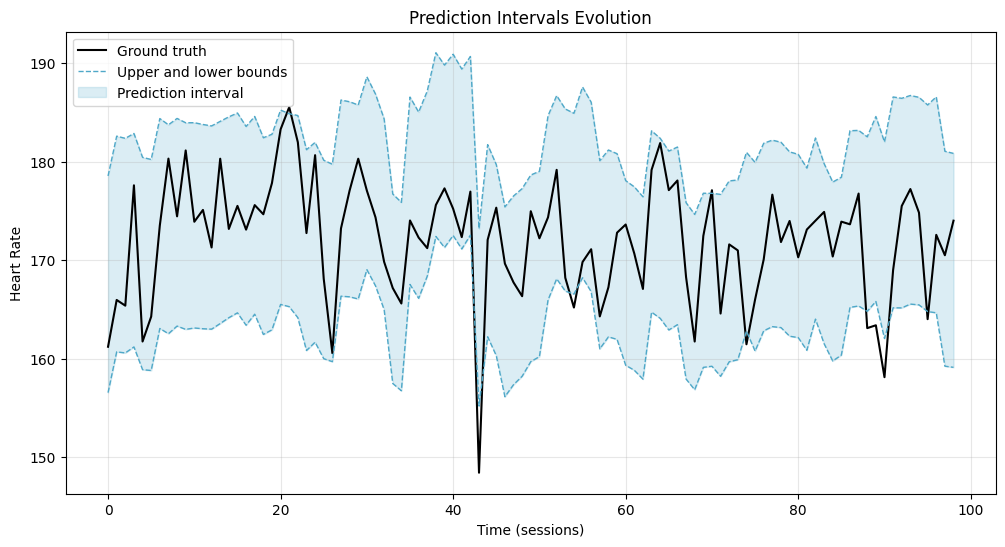

Figure saved


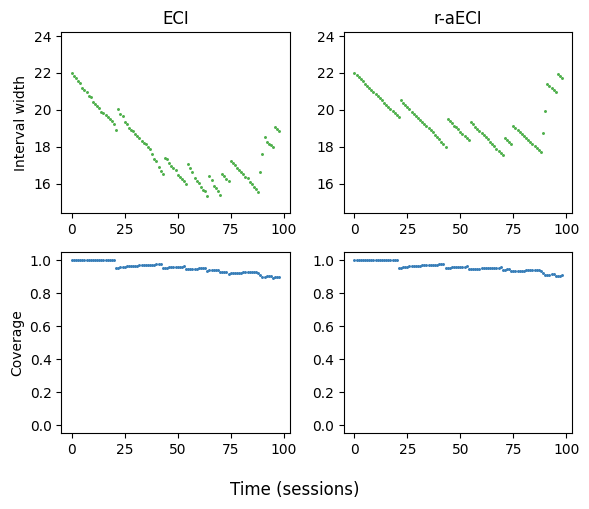

MHSC-72
0.8805970149253731 25.75804327391883 25.021909797571254
0.9029850746268657 34.286375395608005 31.573920903181886
Figure saved


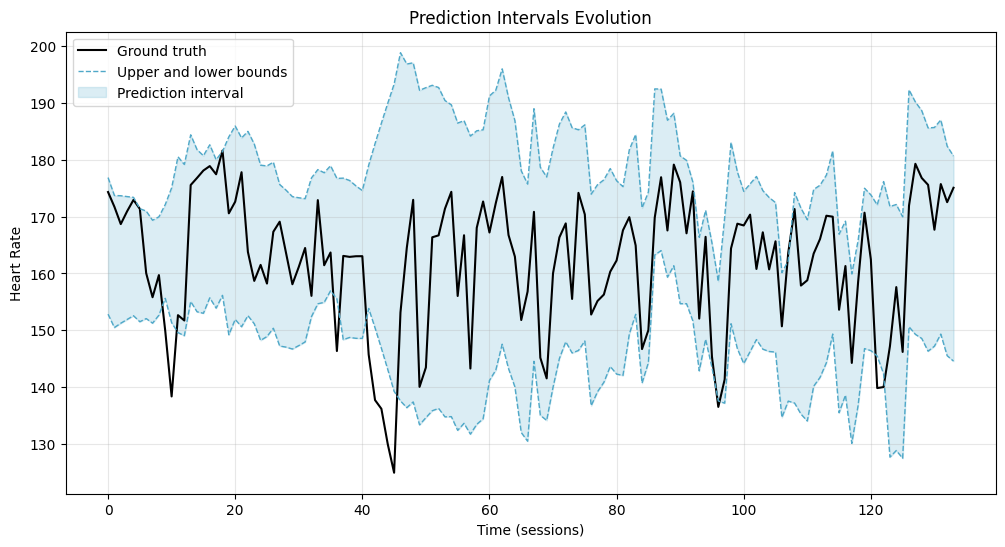

Figure saved


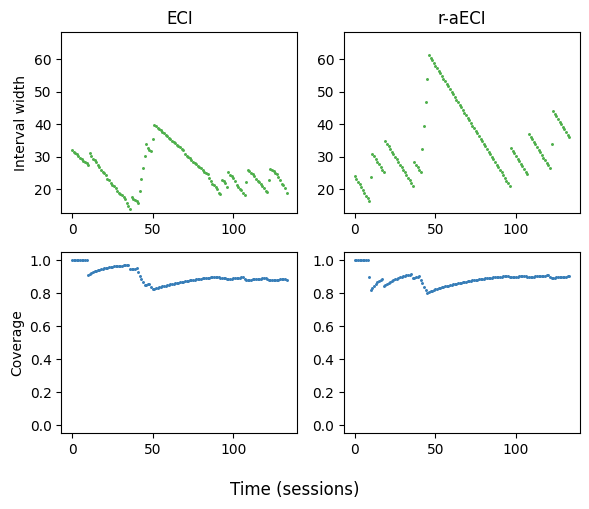

MHSC-73
0.8955223880597015 21.211303805655817 21.179931396675613
0.9104477611940298 21.42723948398207 21.597339767529206
Figure saved


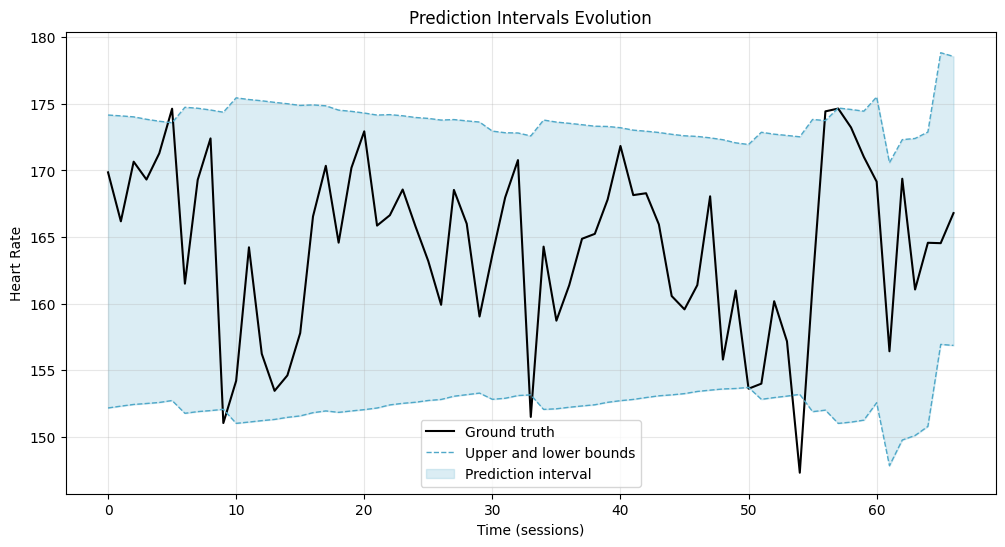

Figure saved


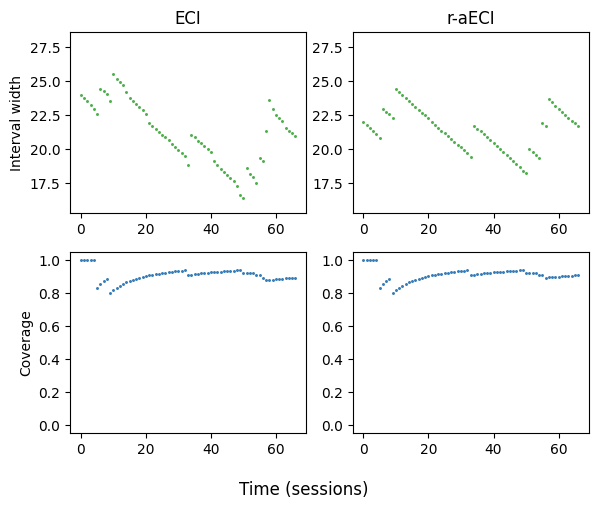

MHSC-75
0.8942307692307693 22.834725475216825 22.82834714895108
0.9038461538461539 22.7679777376543 23.119216483984218
Figure saved


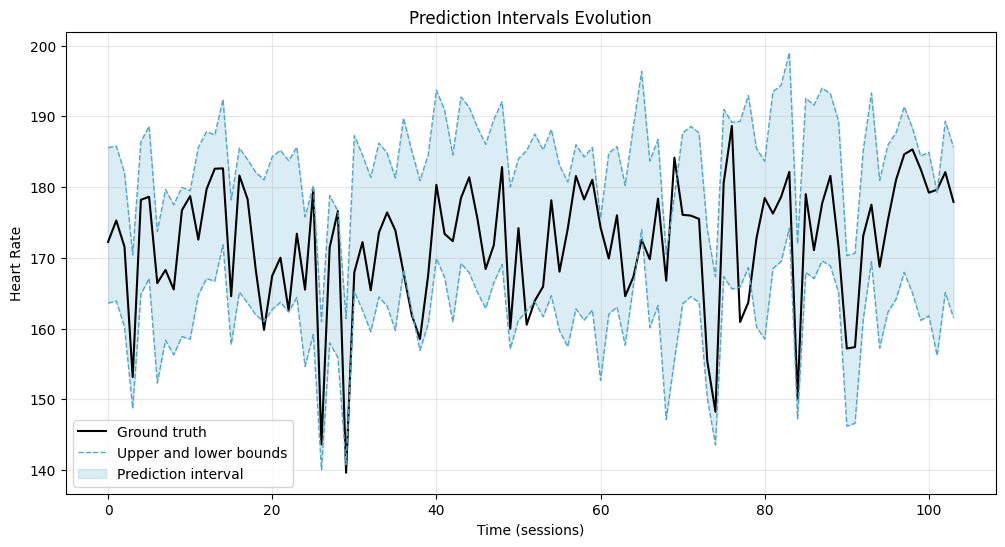

Figure saved


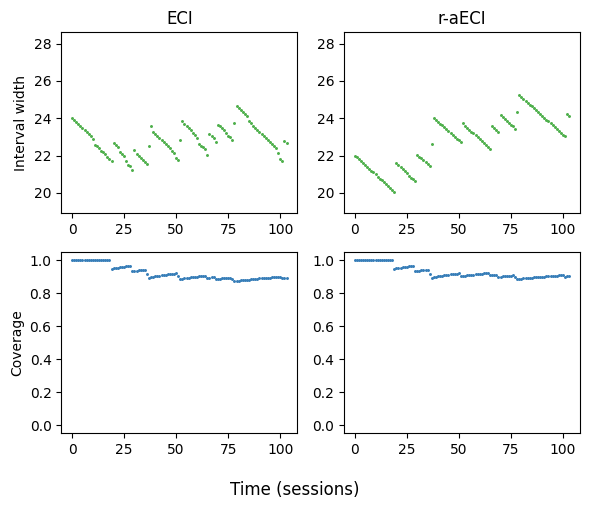

MHSC-77
0.9215686274509803 27.5714142879144 27.529861892952738
0.9215686274509803 28.17122802946957 26.487883648907086
Figure saved


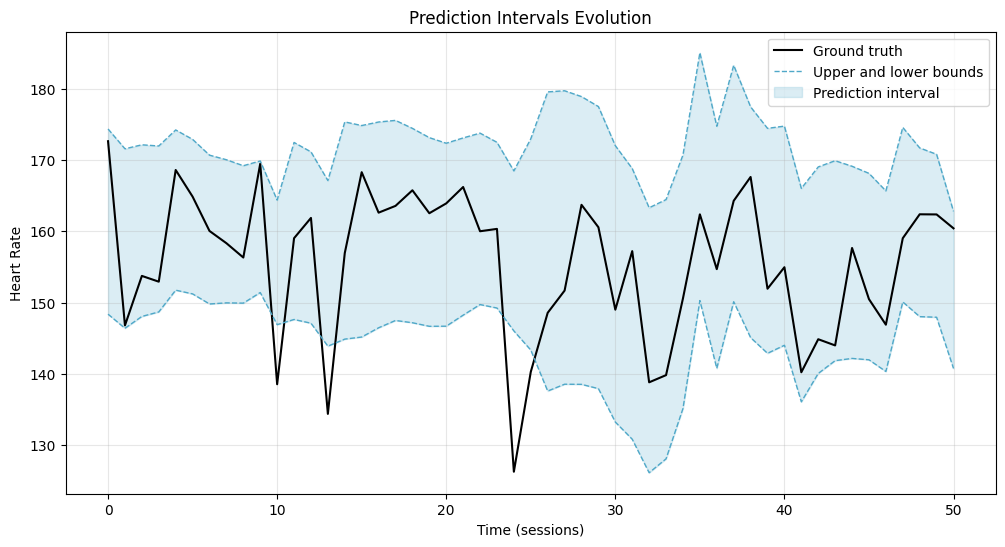

Figure saved


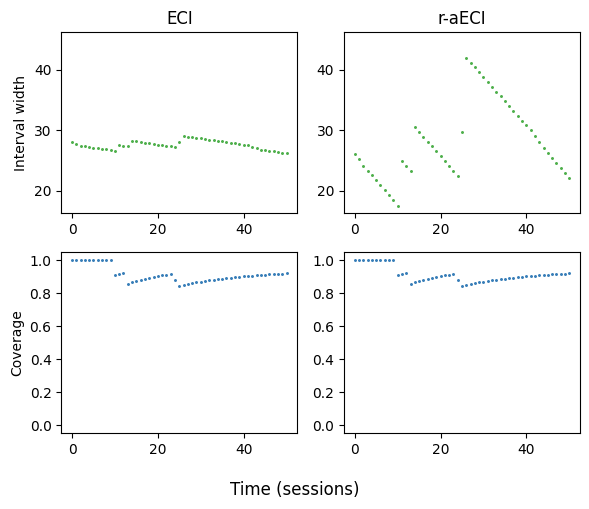

MHSC-78
0.8918918918918919 40.121719561994254 40.0
0.8918918918918919 45.538343339523415 44.051135987785656
Figure saved


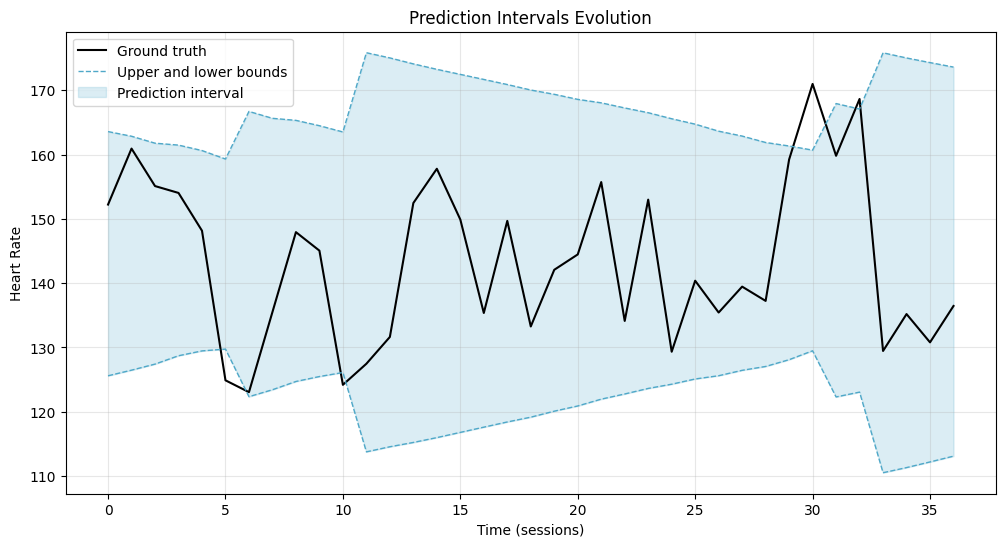

Figure saved


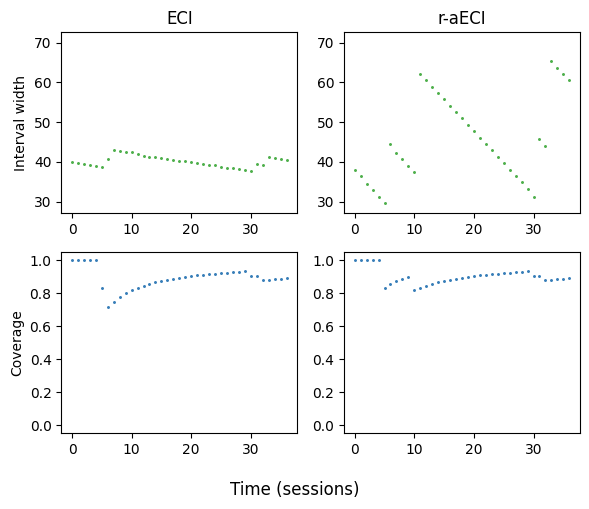

MHSC-79
0.85 30.562431336296203 31.070456896439765
0.85 30.148329823300003 30.826111785825958
Figure saved


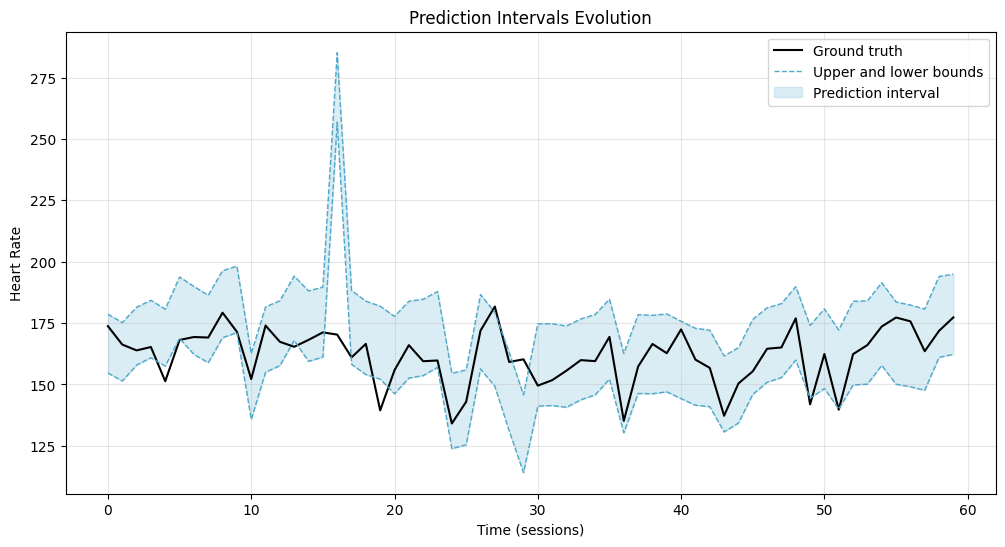

Figure saved


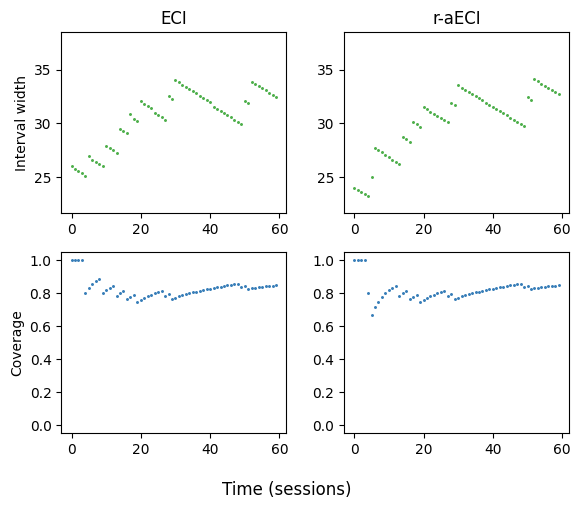

MHSC-81
0.9230769230769231 24.269382748761075 23.861706574746847
0.9487179487179487 24.95179479029078 24.92543480297934
Figure saved


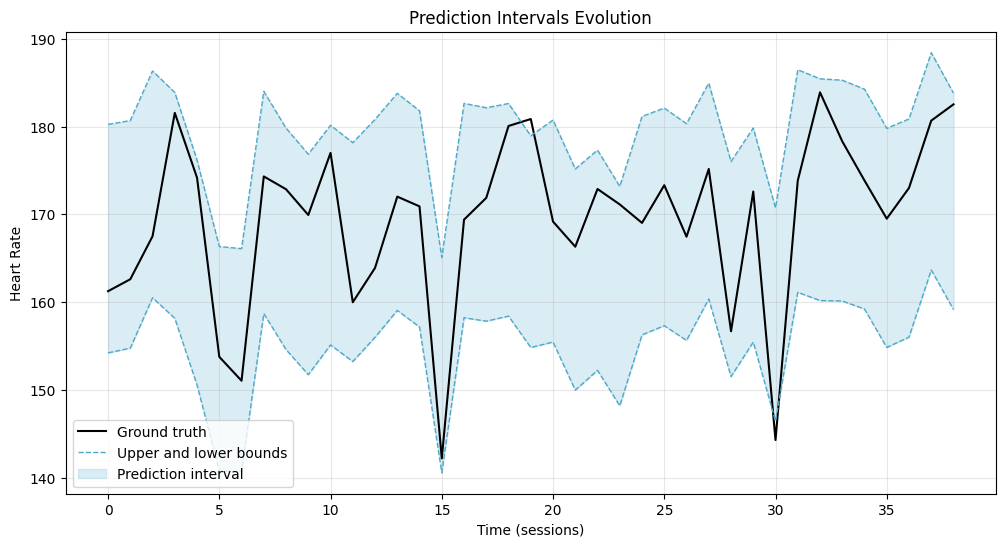

Figure saved


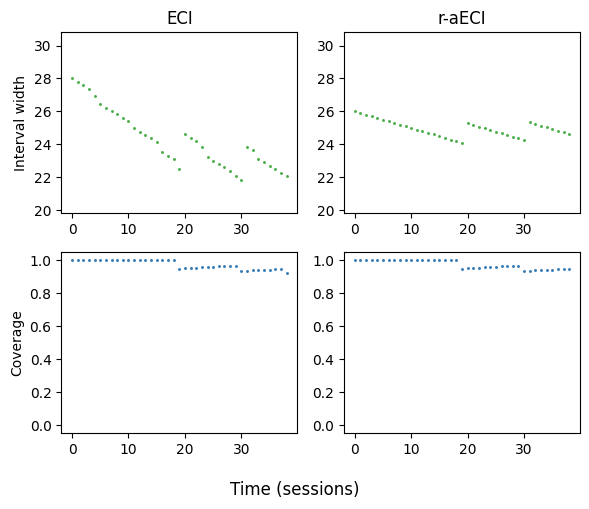

In [2]:
players_all=['MHSC-06','MHSC-07','MHSC-08','MHSC-10','MHSC-11','MHSC-14','MHSC-16','MHSC-17','MHSC-18','MHSC-19',
         'MHSC-20','MHSC-22','MHSC-23','MHSC-25','MHSC-26','MHSC-29','MHSC-32','MHSC-35','MHSC-39','MHSC-41',
         'MHSC-45','MHSC-47','MHSC-49','MHSC-51','MHSC-53','MHSC-54','MHSC-55','MHSC-56','MHSC-59','MHSC-60',
         'MHSC-62','MHSC-65','MHSC-66','MHSC-67','MHSC-68','MHSC-69','MHSC-71','MHSC-72','MHSC-73','MHSC-75',
         'MHSC-77','MHSC-78','MHSC-79','MHSC-81']

players_b=['MHSC-07','MHSC-10','MHSC-11','MHSC-18','MHSC-19','MHSC-22','MHSC-23','MHSC-25','MHSC-29','MHSC-32',
         'MHSC-39','MHSC-51','MHSC-55','MHSC-56','MHSC-59','MHSC-62','MHSC-65','MHSC-66','MHSC-67','MHSC-71',
         'MHSC-73','MHSC-75','MHSC-81']

remaining_players=[player for player in players_all if player not in players_b]
with open('results/ECI_best_hyperparams.pkl', 'rb') as handle:
    best_results=pickle.load(handle)

dataset="HR"
basemodel="KR"
size_train=0.7
cv_search=5
cv_method="TSSplit" #with train_opt always TimeSeriesSplit for CV search of the regressor
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method="ECI"

rows=[]
method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

#TODO change to players_all
for player in players_all:
    print(player)
    method_params_player=best_results[player]
    method_params_player['ECI_sig']['f_dev']=dev_sigmoid_c(1)
    method_params_player['ECI_my']['f_dev']=dev_f_w_v(w,np.array([method_params_player['ECI_my']['v']]),alpha)
    name_methods=list(method_params_player.keys())
    df_player=load_player(df,player)
    results=dict.fromkeys(name_methods)
    nb_obervations=df_player.shape[0]
    # start_train=1
    # end_train=int(nb_obervations*size_train)
    # start_test=end_train+1
    # end_test=nb_obervations
    start_train=1
    end_train=int(nb_obervations*size_train)
    start_test=end_train+1
    end_test=nb_obervations
    for name_method,params in method_params_player.items(): 
        result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q_0'],lr=params['l_r'],f_dev=params['f_dev'])
        results[name_method]=result
        cov,mean_width,median_width,std_width=means_exp(result)
        player_number='Player '+player.split('-')[1]
        rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width,"width_median":median_width,"width_std":std_width,"coverage":cov})
        print(cov,mean_width,median_width) 
        #print(f' & {round(cov,2)}   & {round(mean_width,1)}  & {round(median_width,1)}')
    title=f'exp2_{dataset}_{player}_{basemodel}'
    title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'

    plot_evolution(results["ECI_my"],title_interval)
    plot_exp(title,results,name_methods,method_to_title)


In [13]:
df=pd.DataFrame(rows)
df_ECI=df[df['method']=="ECI"]
df_raECI=df[df['method']=="r-aECI"]
mean_std_ECI=df_ECI["width_std"].mean()
mean_std_raECI=df_raECI["width_std"].mean()
print(mean_std_ECI,mean_std_raECI)

3.28916698489346 3.631856734545772


##### Wilcoxon test

In [5]:
import scipy

df=pd.DataFrame(rows)
df_ECI=df[df['method']=="ECI"]
df_raECI=df[df['method']=="r-aECI"]
diff=df_raECI["width_mean"].to_numpy()-df_ECI["width_mean"].to_numpy() 
stat,p=scipy.stats.wilcoxon(diff)

print("p_value =", p)
print("Median r-aECI-ECI:", np.median(diff))
print("r-aECI > ECI:", np.mean((diff > 0)))
print("r-aECI < ECI:", np.mean((diff < 0)))
print("r-aECI = ECI:", np.mean((diff == 0)))

p_value = 0.05136492735891807
Median r-aECI-ECI: 0.27043424269962735
r-aECI > ECI: 0.6136363636363636
r-aECI < ECI: 0.38636363636363635
r-aECI = ECI: 0.0


##### Graph

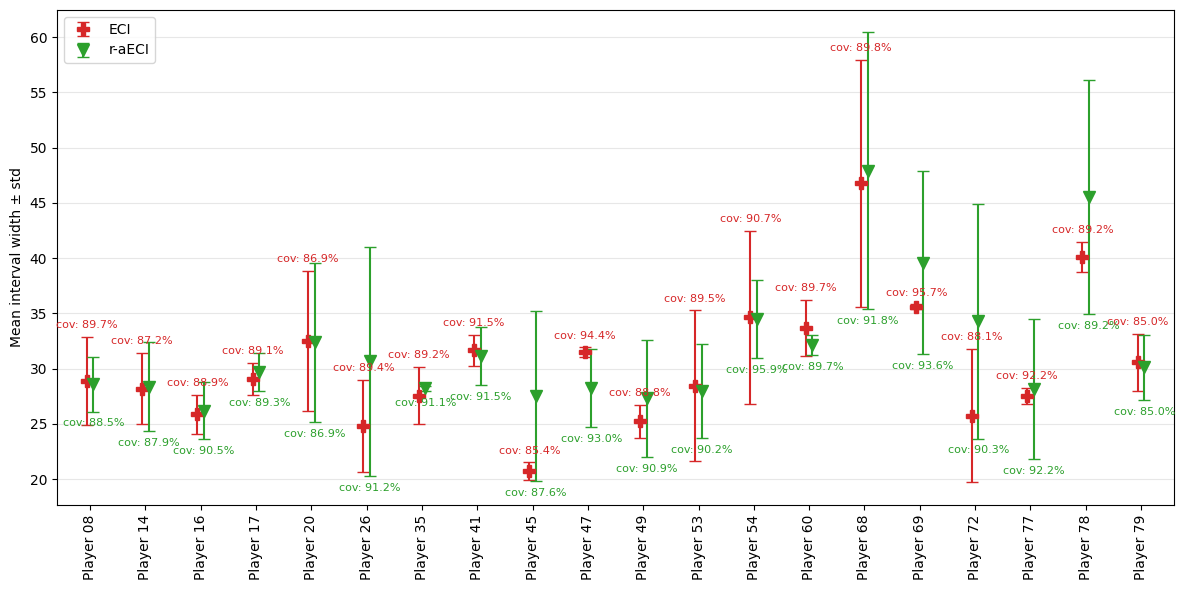

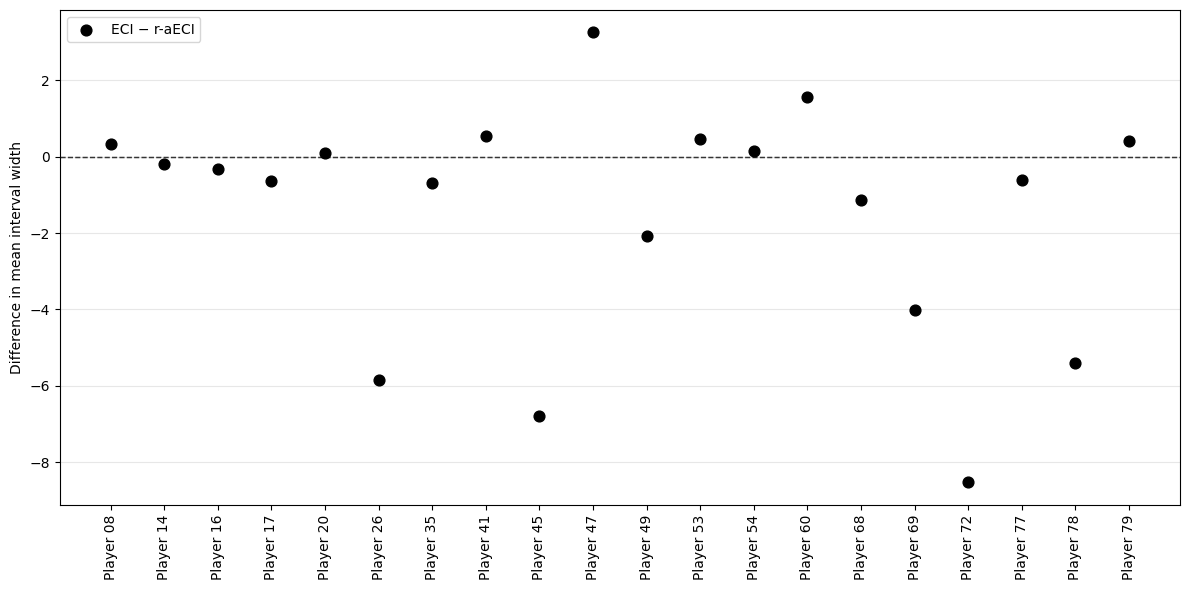

In [5]:
players=['Player 07','Player 10','Player 11','Player 18','Player 19','Player 22','Player 23','Player 25','Player 29','Player 32',
         'Player 39','Player 51','Player 55','Player 56','Player 59','Player 62','Player 65','Player 66','Player 67','Player 71',
         'Player 73','Player 75','Player 81']
players_appendix=['Player 08', 'Player 14', 'Player 16', 'Player 17', 'Player 20', 'Player 26', 'Player 35', 'Player 41', 'Player 45',
                  'Player 47', 'Player 49', 'Player 53', 'Player 54', 'Player 60', 'Player 68', 'Player 69', 'Player 72', 'Player 77', 'Player 78',
                  'Player 79']
#TODO Player 06
methods=["ECI","r-aECI"]

# import pickle
# try:
#     with open('results/ECI_rows.pkl', 'rb') as handle:
#         rows=pickle.load(handle)
# except:
#     with open('results/ECI_rows.pkl', 'wb') as handle:
#         pickle.dump(rows,handle)

plot_interval_widths_by_player(rows,'dumbbell_ECI_raECI_rem',players_appendix,methods)
plot_difference_by_player(rows,'difference_ECI_raECI_rem',methods,players_appendix)